Import Required Libraries

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')
import os
import joblib

Set Up Directories

In [144]:
import os

BASE_DIR = os.getcwd()  # Gets the current notebook's working directory
DATA_DIR = os.path.join(BASE_DIR, 'data')
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
MODEL_DIR = os.path.join(BASE_DIR, 'models')

for directory in [DATA_DIR, OUTPUT_DIR, MODEL_DIR]:
    os.makedirs(directory, exist_ok=True)

============================================================
TITANIC SURVIVAL PREDICTION PROJECT
============================================================

Step 1: Load and Explore the Data

In [145]:
import seaborn as sns

df = sns.load_dataset('titanic')
print(f"Dataset loaded successfully! Shape: {df.shape}")

Dataset loaded successfully! Shape: (891, 15)


In [146]:
df.rename(columns={'survived':'Survived', 'pclass':'Pclass', 'sex':'Sex', 
                   'age':'Age', 'sibsp':'SibSp', 'parch':'Parch', 
                   'fare':'Fare', 'embarked':'Embarked'}, inplace=True)

Dataset loaded successfully! Shape: (891, 12)

First 5 rows of the dataset:
   PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0            1         0       3  ...   7.2500   NaN         S
1            2         1       1  ...  71.2833   C85         C
2            3         1       3  ...   7.9250   NaN         S
3            4         1       1  ...  53.1000  C123         S
4            5         0       3  ...   8.0500   NaN         S

[5 rows x 12 columns]

----------------------------------------
DATASET INFORMATION:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.6+ KB

----------------------------------------
STATISTICAL SUMMARY:
----------------------------------------
       PassengerId    Survived      Pclass         Age       SibSp  ...        Fare
count   891.000000  891.000000  891.000000  714.000000  891.000000  ...  891.000000
mean    446.000000    0.383838    2.308642   29.699118    0.523008  ...   32.204208
std     257.353842    0.486592    0.836071   14.526497    1.102743  ...   49.693429
min       1.000000    0.000000    1.000000    0.420000    0.000000  ...    0.000000
25%     223.500000    0.000000    2.000000   20.125000    0.000000  ...    7.910400
50%     446.000000    0.000000    3.000000   28.000000    0.000000  ...   14.454200
75%     668.500000    1.000000    3.000000   38.000000    1.000000  ...   31.000000
max     891.000000    1.000000    3.000000   80.000000    8.000000  ...  512.329200

[8 rows x 7 columns]

----------------------------------------
MISSING VALUES:
----------------------------------------
          Missing Count  Missing %
Age                 177  19.865319
Cabin               687  77.104377
Embarked              2   0.224467

Step 2: Exploratory Data Analysis and Visualizations

In [147]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")

# 2.1 Survival Distribution (Pie Chart)
plt.figure(figsize=(10, 6))
survival_counts = df['Survived'].value_counts()
colors = ['#ff6b6b', '#51cf66']
plt.pie(survival_counts, labels=['Not Survived', 'Survived'], 
        autopct='%1.1f%%', startangle=90, colors=colors,
        explode=(0.05, 0.05), shadow=True)
plt.title('Titanic Passenger Survival Distribution', fontsize=16, fontweight='bold')
plt.savefig(os.path.join(OUTPUT_DIR, '1_survival_distribution_pie.png'), dpi=300, bbox_inches='tight')
plt.close()

Figure 1_survival_distribution_pie– shows 38.4% survived, 61.6% not.

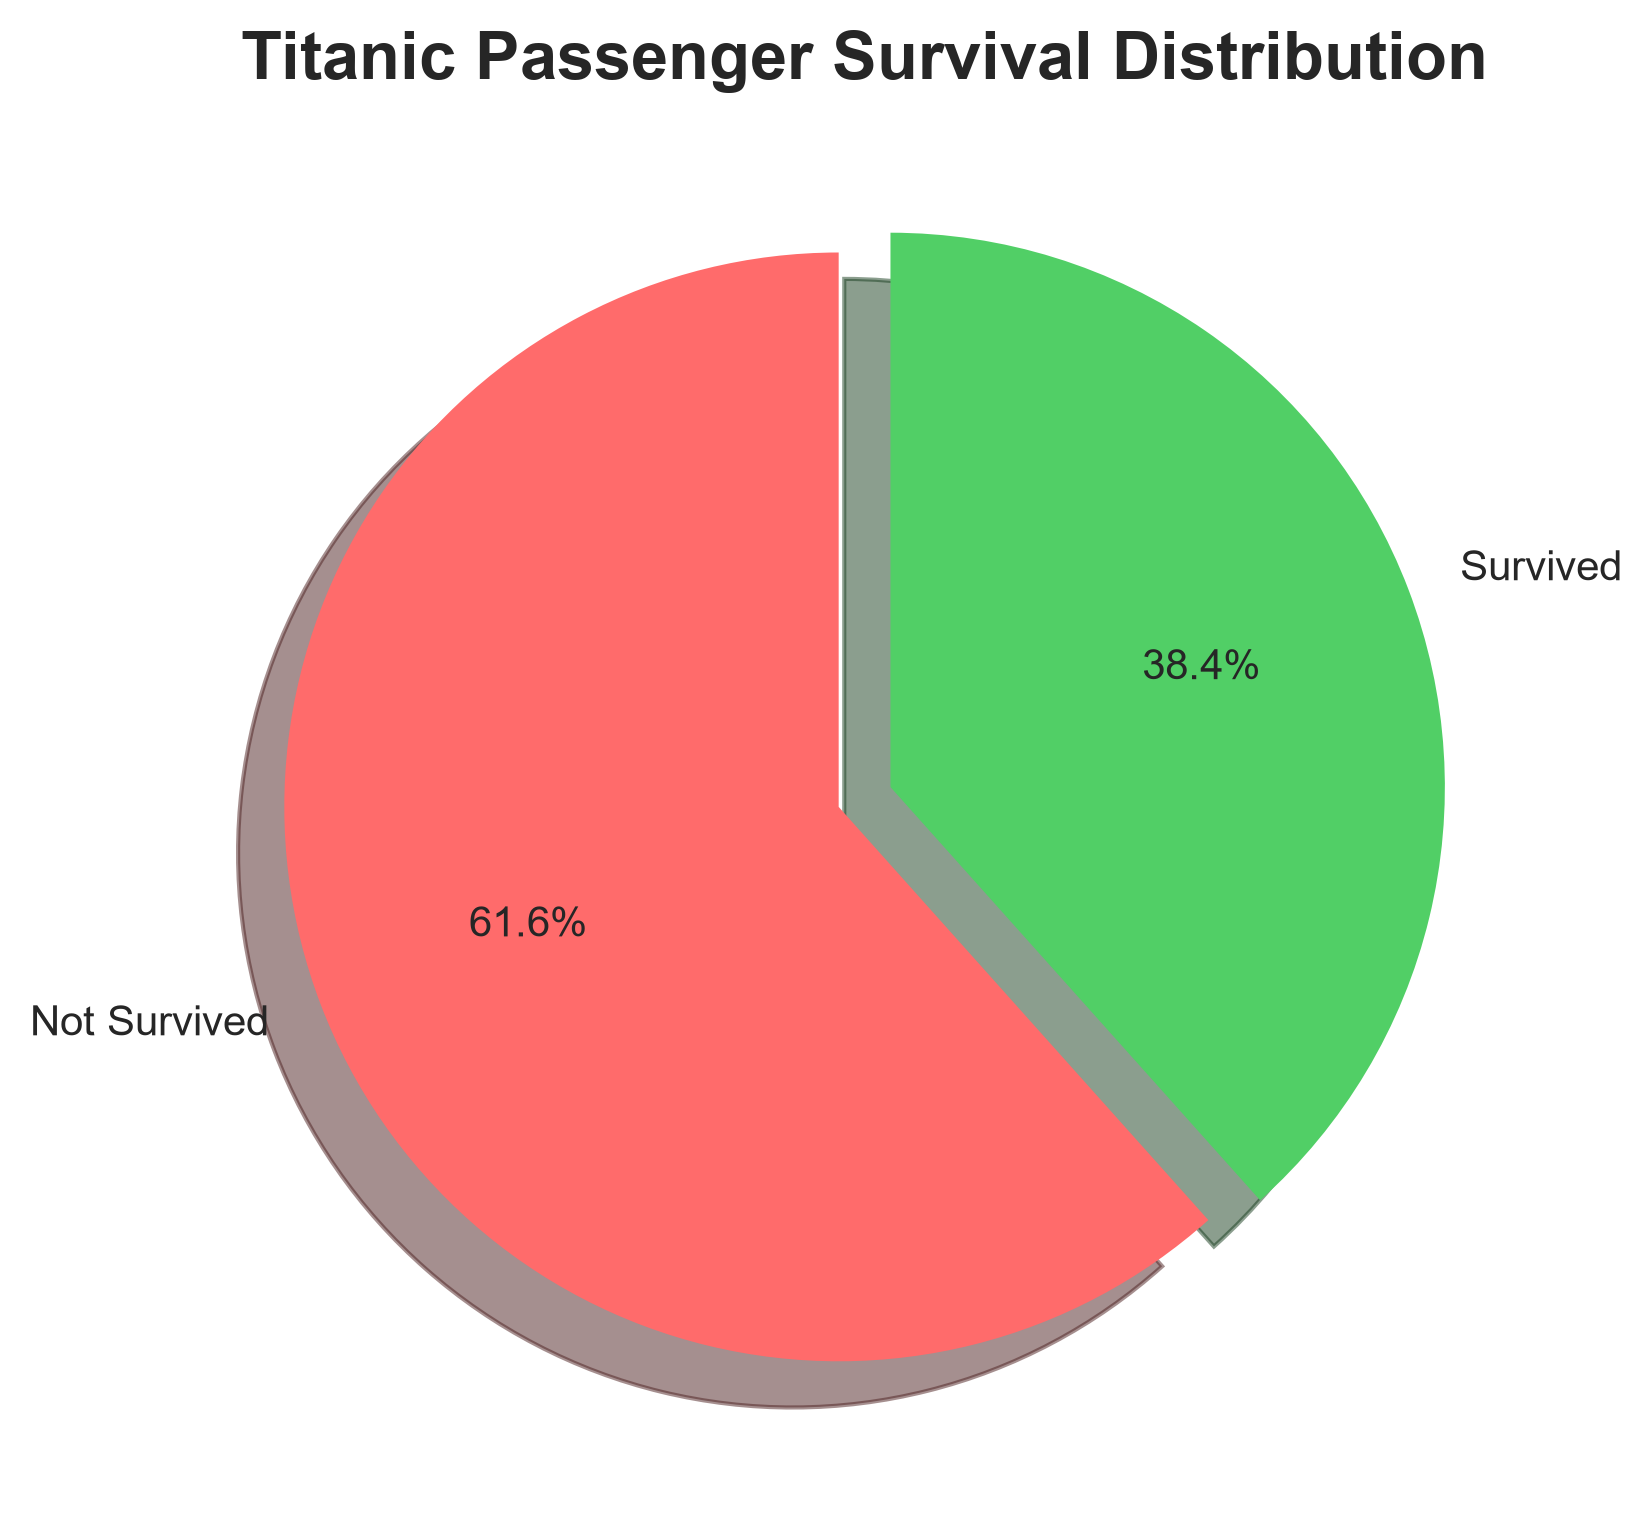

In [148]:
# 2.2 Survival by Gender
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Sex', hue='Survived', palette=['#ff6b6b', '#51cf66'])
plt.title('Survival by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Not Survived', 'Survived'])
plt.savefig(os.path.join(OUTPUT_DIR, '2_survival_by_gender.png'), dpi=300, bbox_inches='tight')
plt.close()

Figure 2_survival_by_gender – females show higher survival.

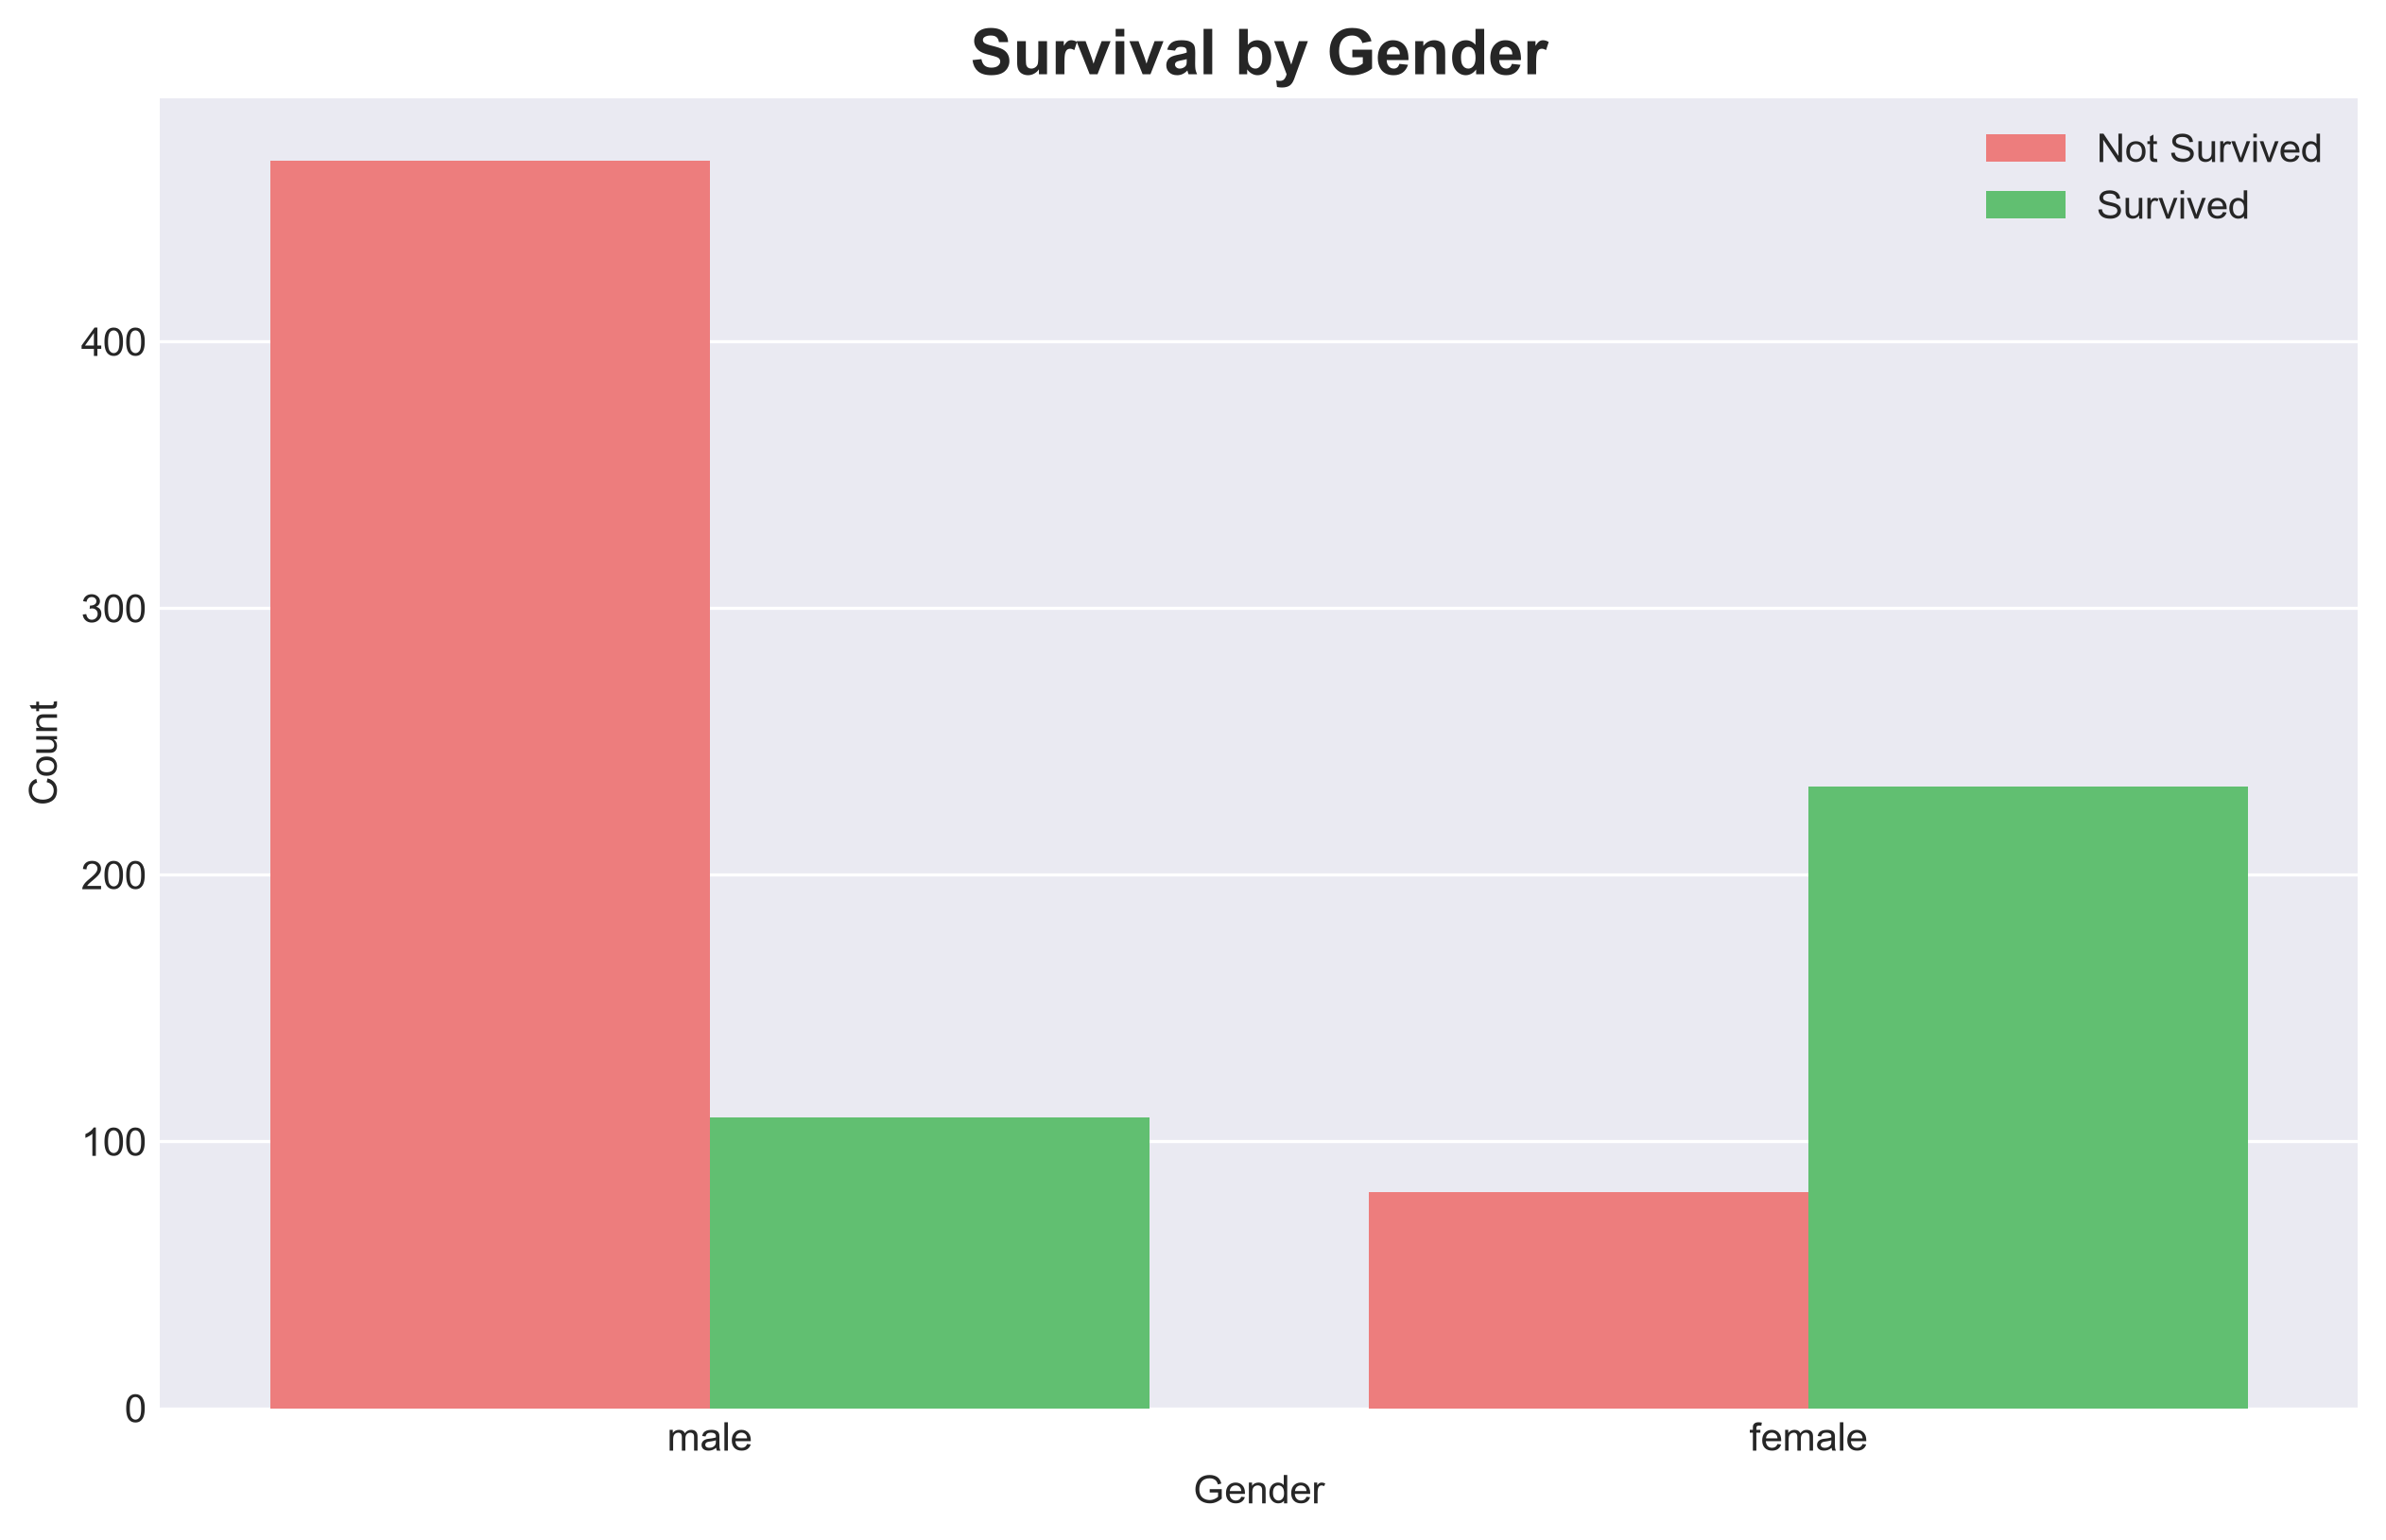

In [149]:
# 2.3 Survival by Passenger Class
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Pclass', hue='Survived', palette=['#ff6b6b', '#51cf66'])
plt.title('Survival by Passenger Class', fontsize=16, fontweight='bold')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(['Not Survived', 'Survived'])
plt.savefig(os.path.join(OUTPUT_DIR, '3_survival_by_class.png'), dpi=300, bbox_inches='tight')
plt.close()

Figure 3_survival_by_class – 1st class had higher survival.

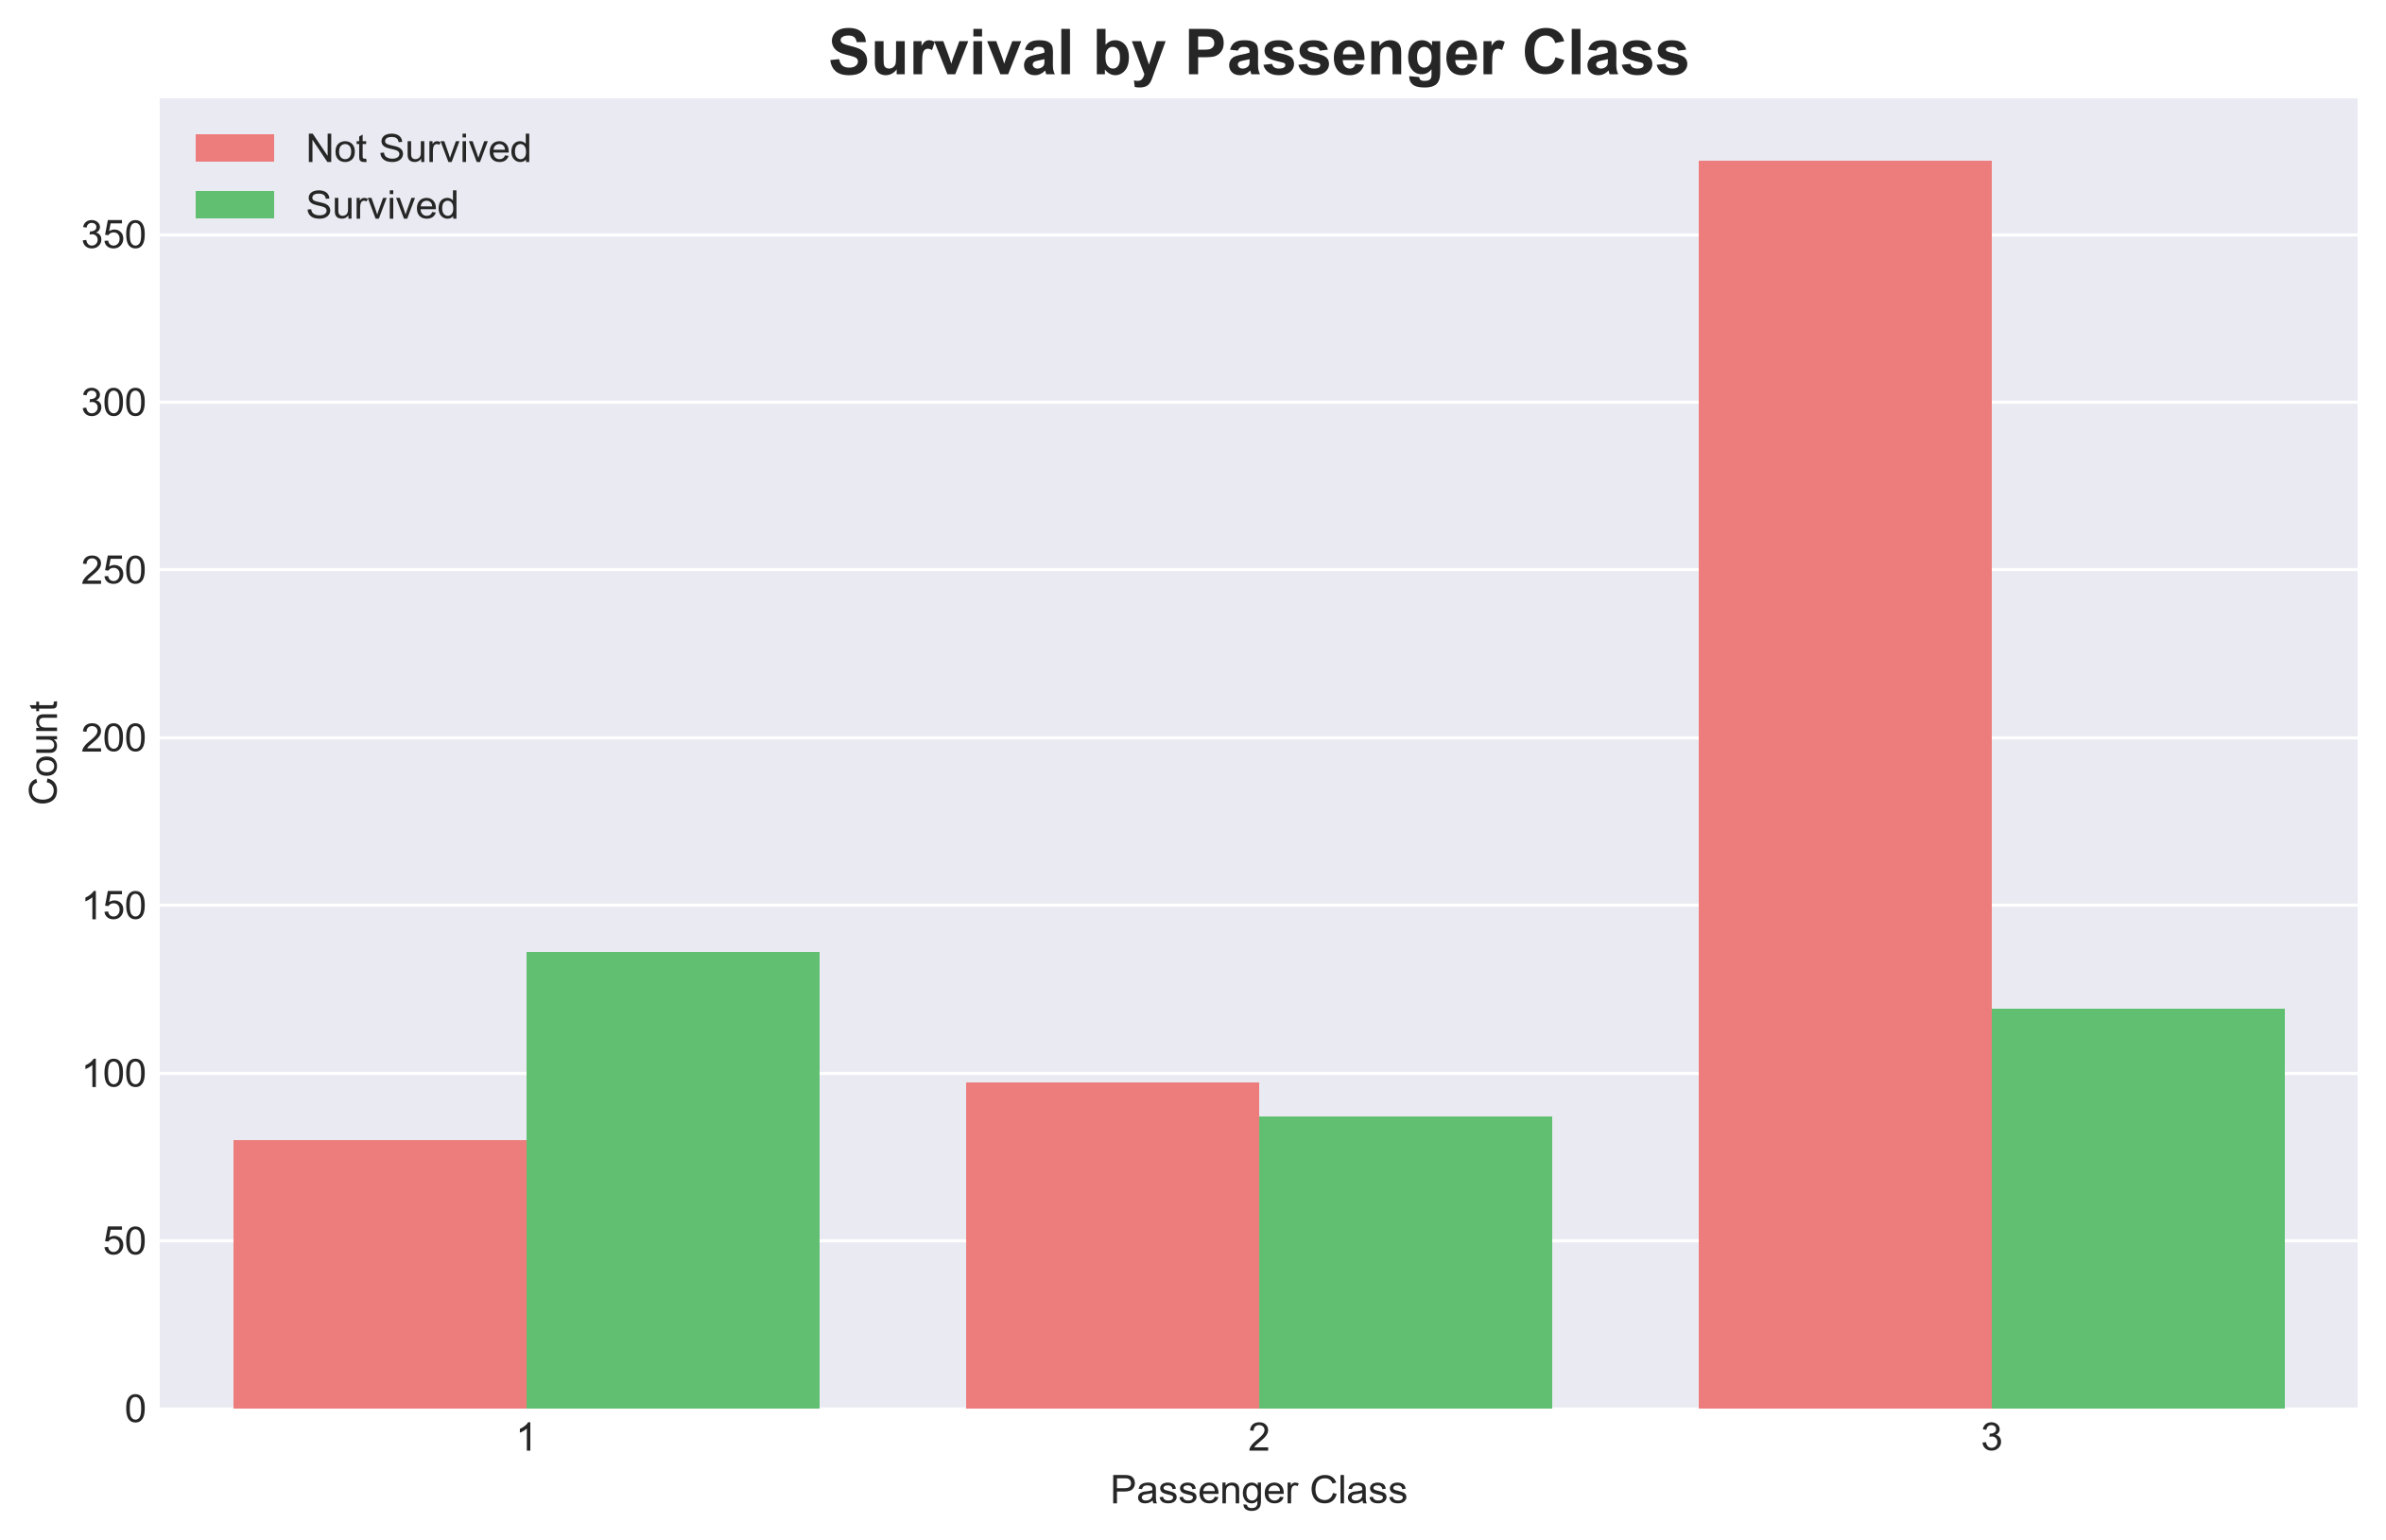

In [150]:
# 2.4 Age Distribution by Survival
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30, palette=['#ff6b6b', '#51cf66'])
plt.title('Age Distribution by Survival', fontsize=16, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(['Not Survived', 'Survived'])
plt.savefig(os.path.join(OUTPUT_DIR, '4_age_distribution_by_survival.png'), dpi=300, bbox_inches='tight')
plt.close()

Figure 4_age_distribution_by_survival – survivors tend to be younger.

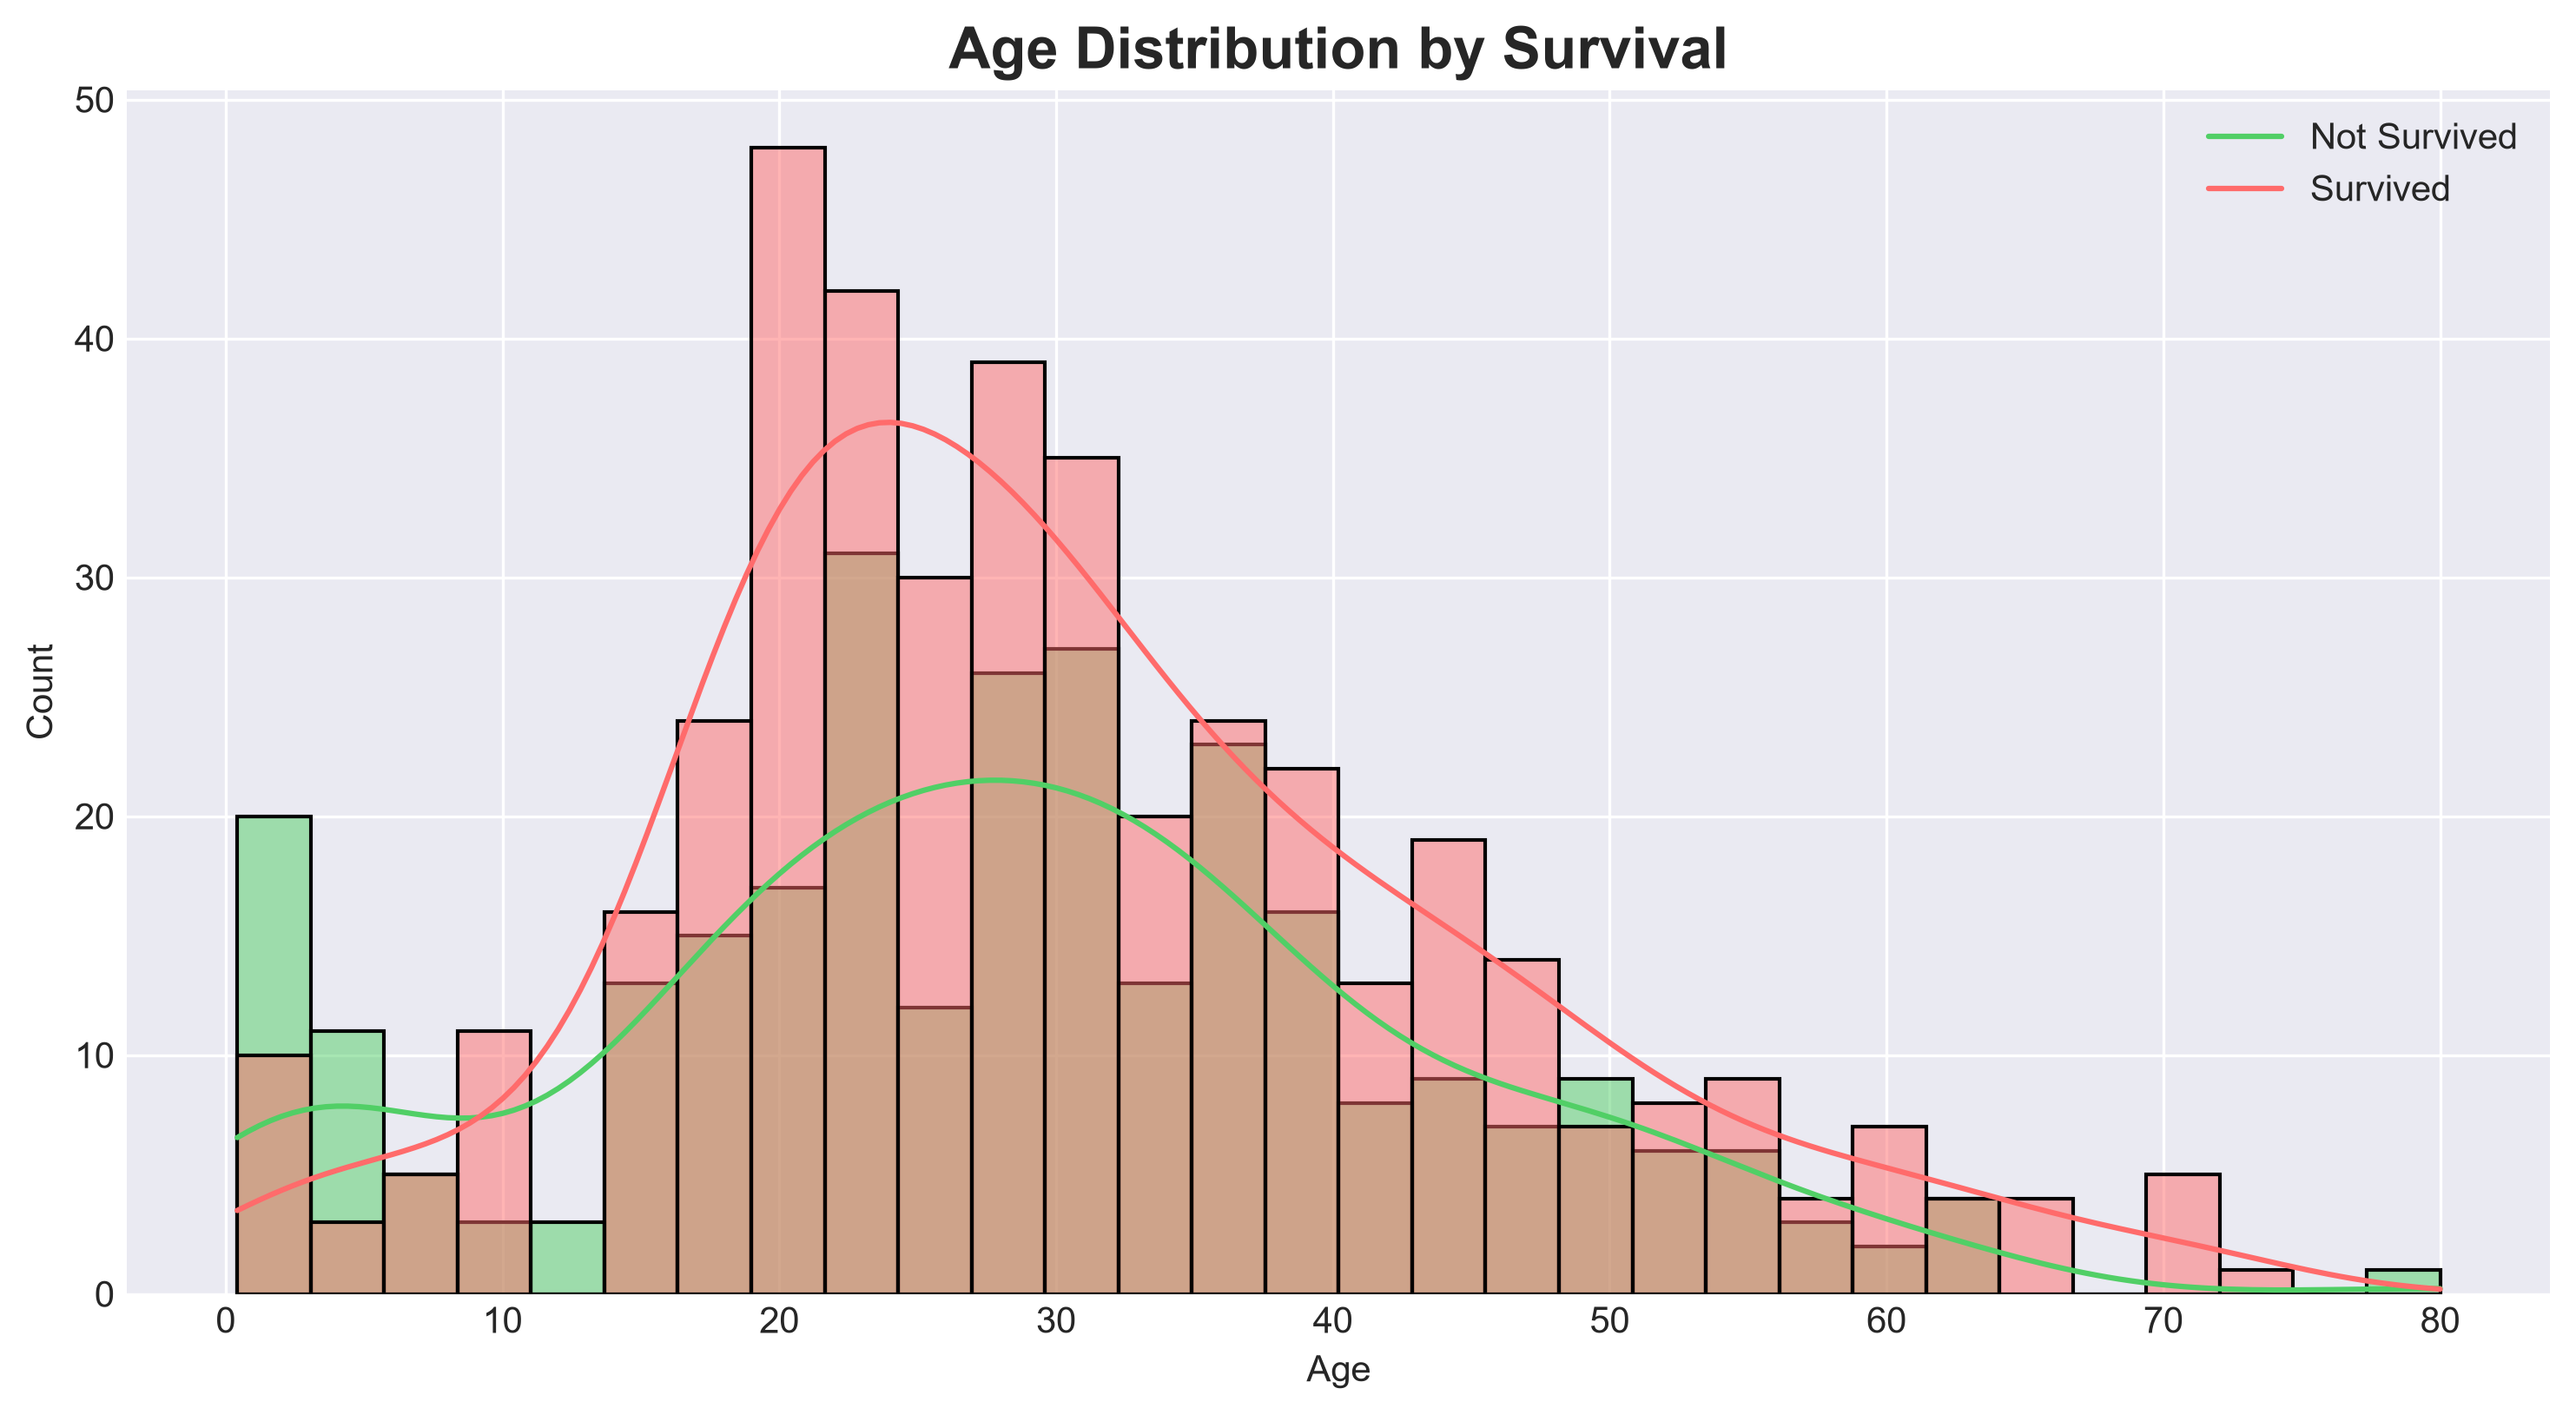

In [151]:
# 2.5 Fare Distribution by Survival
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Fare', hue='Survived', kde=True, bins=30, palette=['#ff6b6b', '#51cf66'])
plt.title('Fare Distribution by Survival', fontsize=16, fontweight='bold')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.xlim(0, 300)
plt.legend(['Not Survived', 'Survived'])
plt.savefig(os.path.join(OUTPUT_DIR, '5_fare_distribution_by_survival.png'), dpi=300, bbox_inches='tight')
plt.close()

Figure 5_fare_distribution_by_survival – survivors paid higher fares.

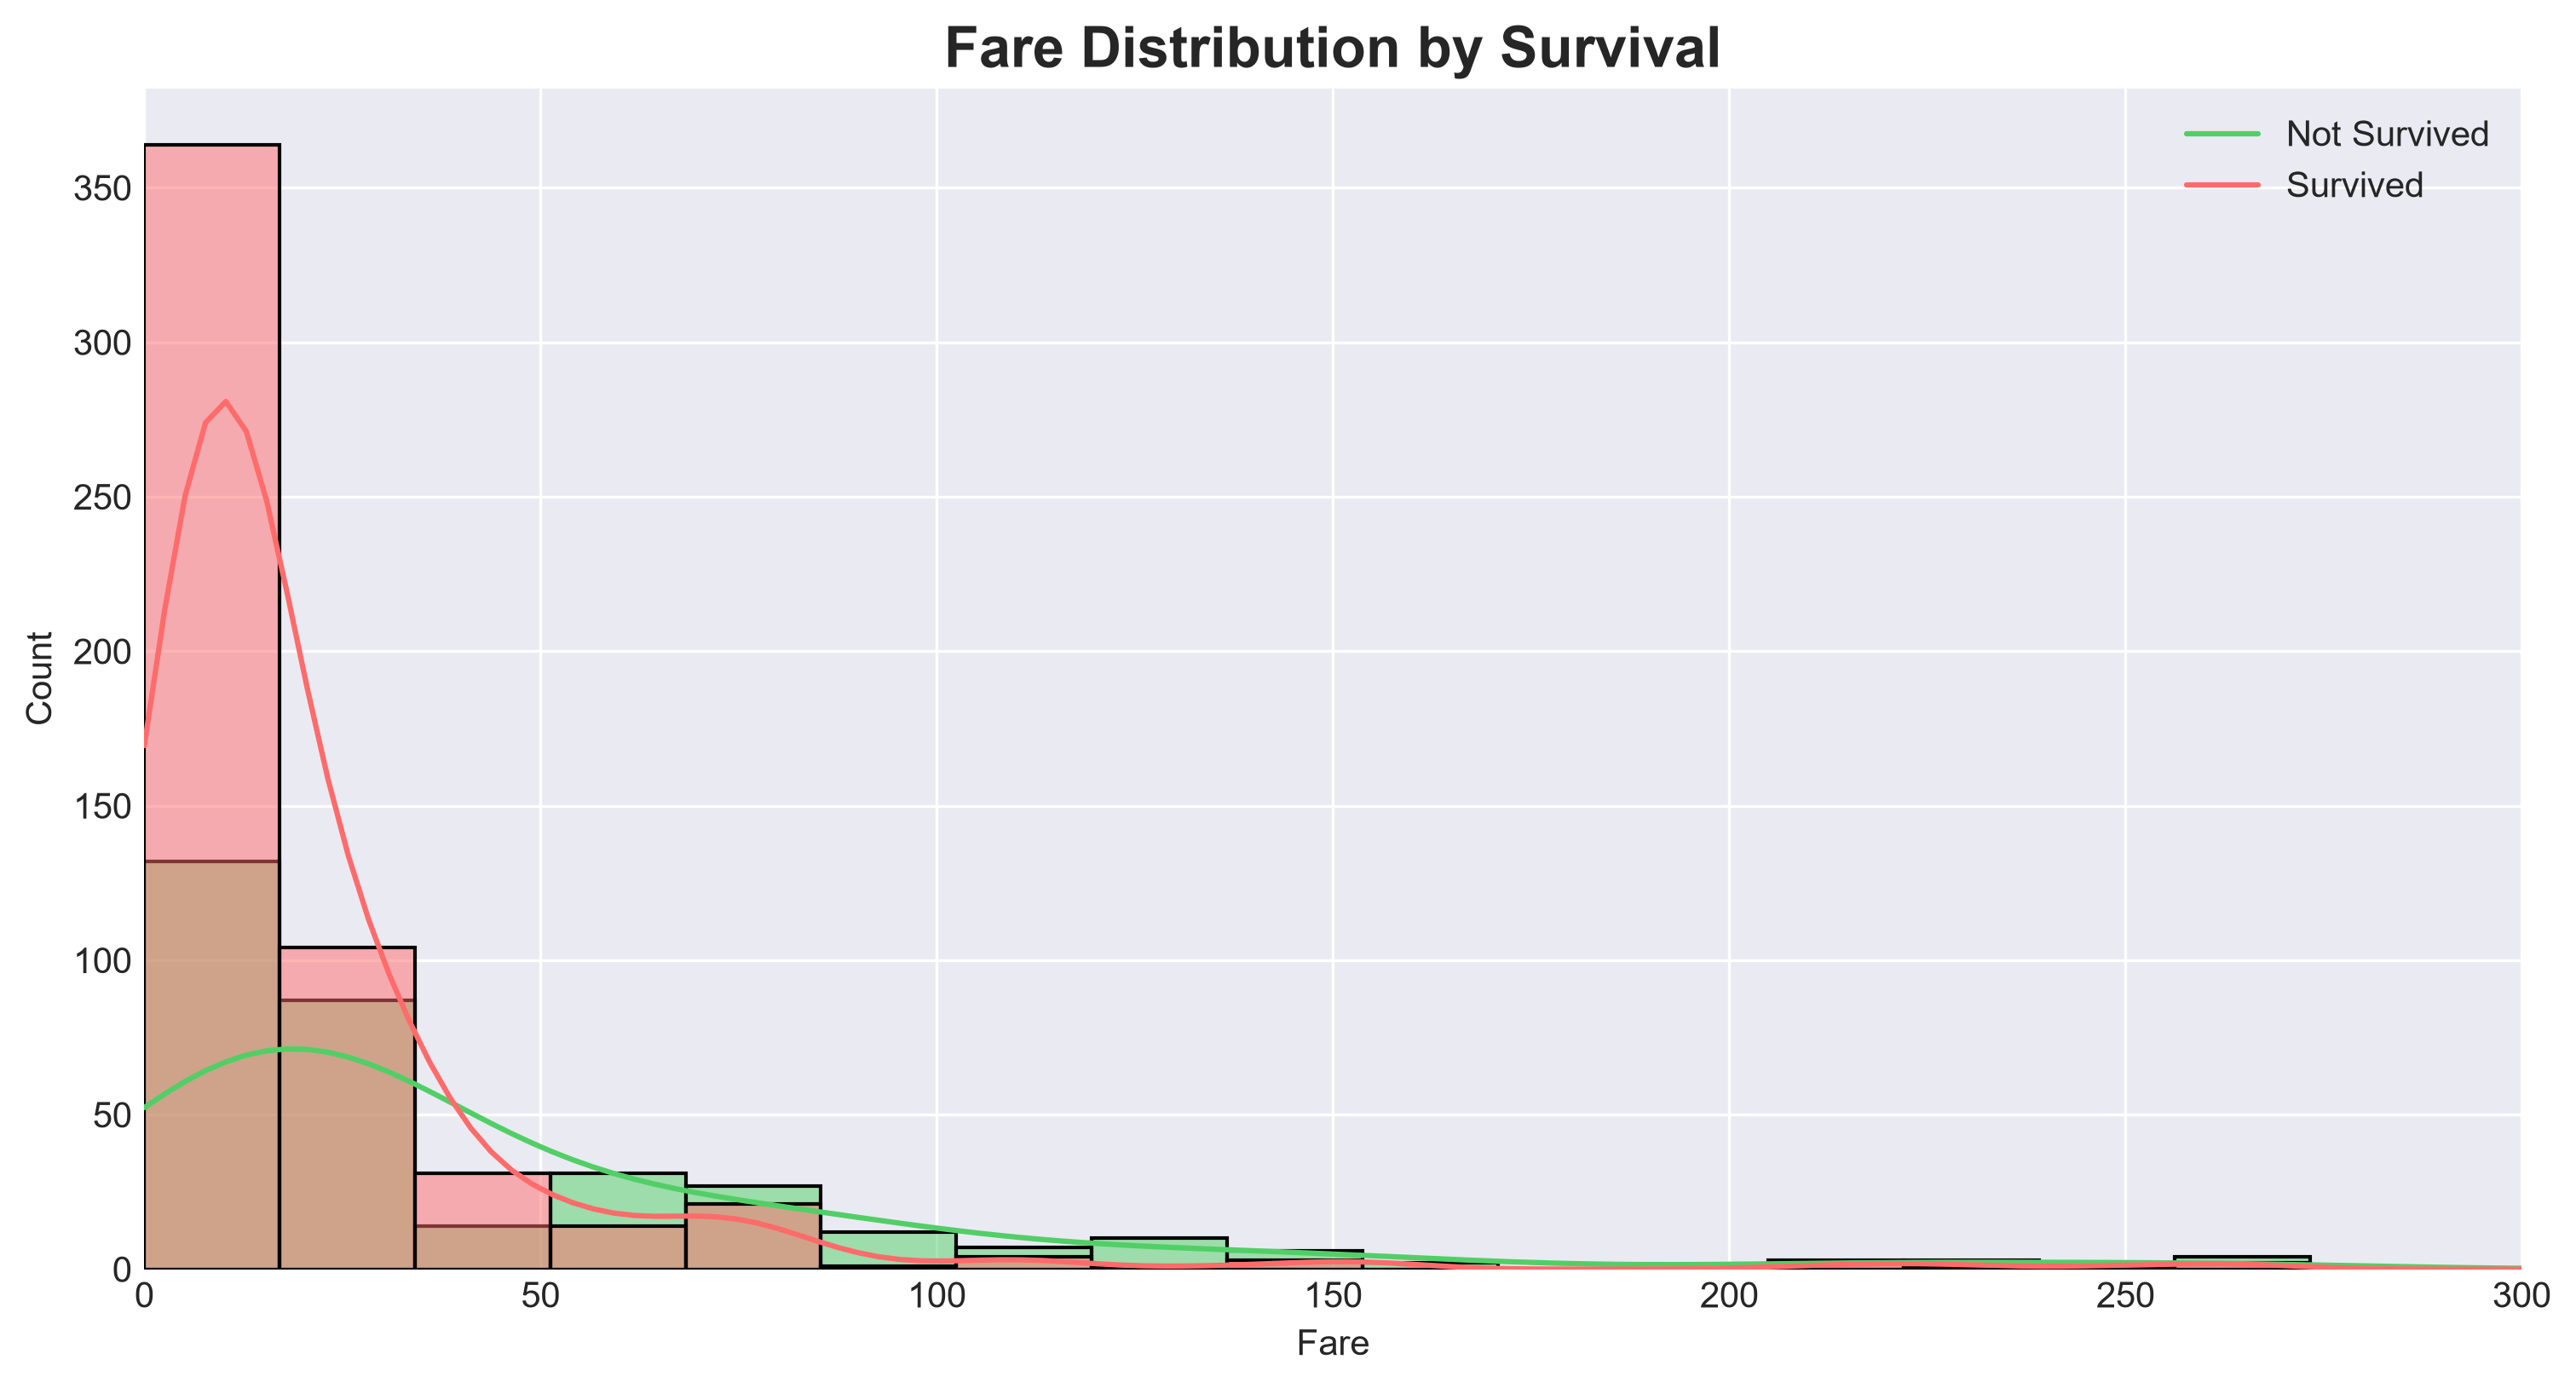

In [152]:
# 2.6 Correlation Heatmap
plt.figure(figsize=(12, 10))
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, mask=mask)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.savefig(os.path.join(OUTPUT_DIR, '6_correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.close()

Figure 6_correlation_heatmap

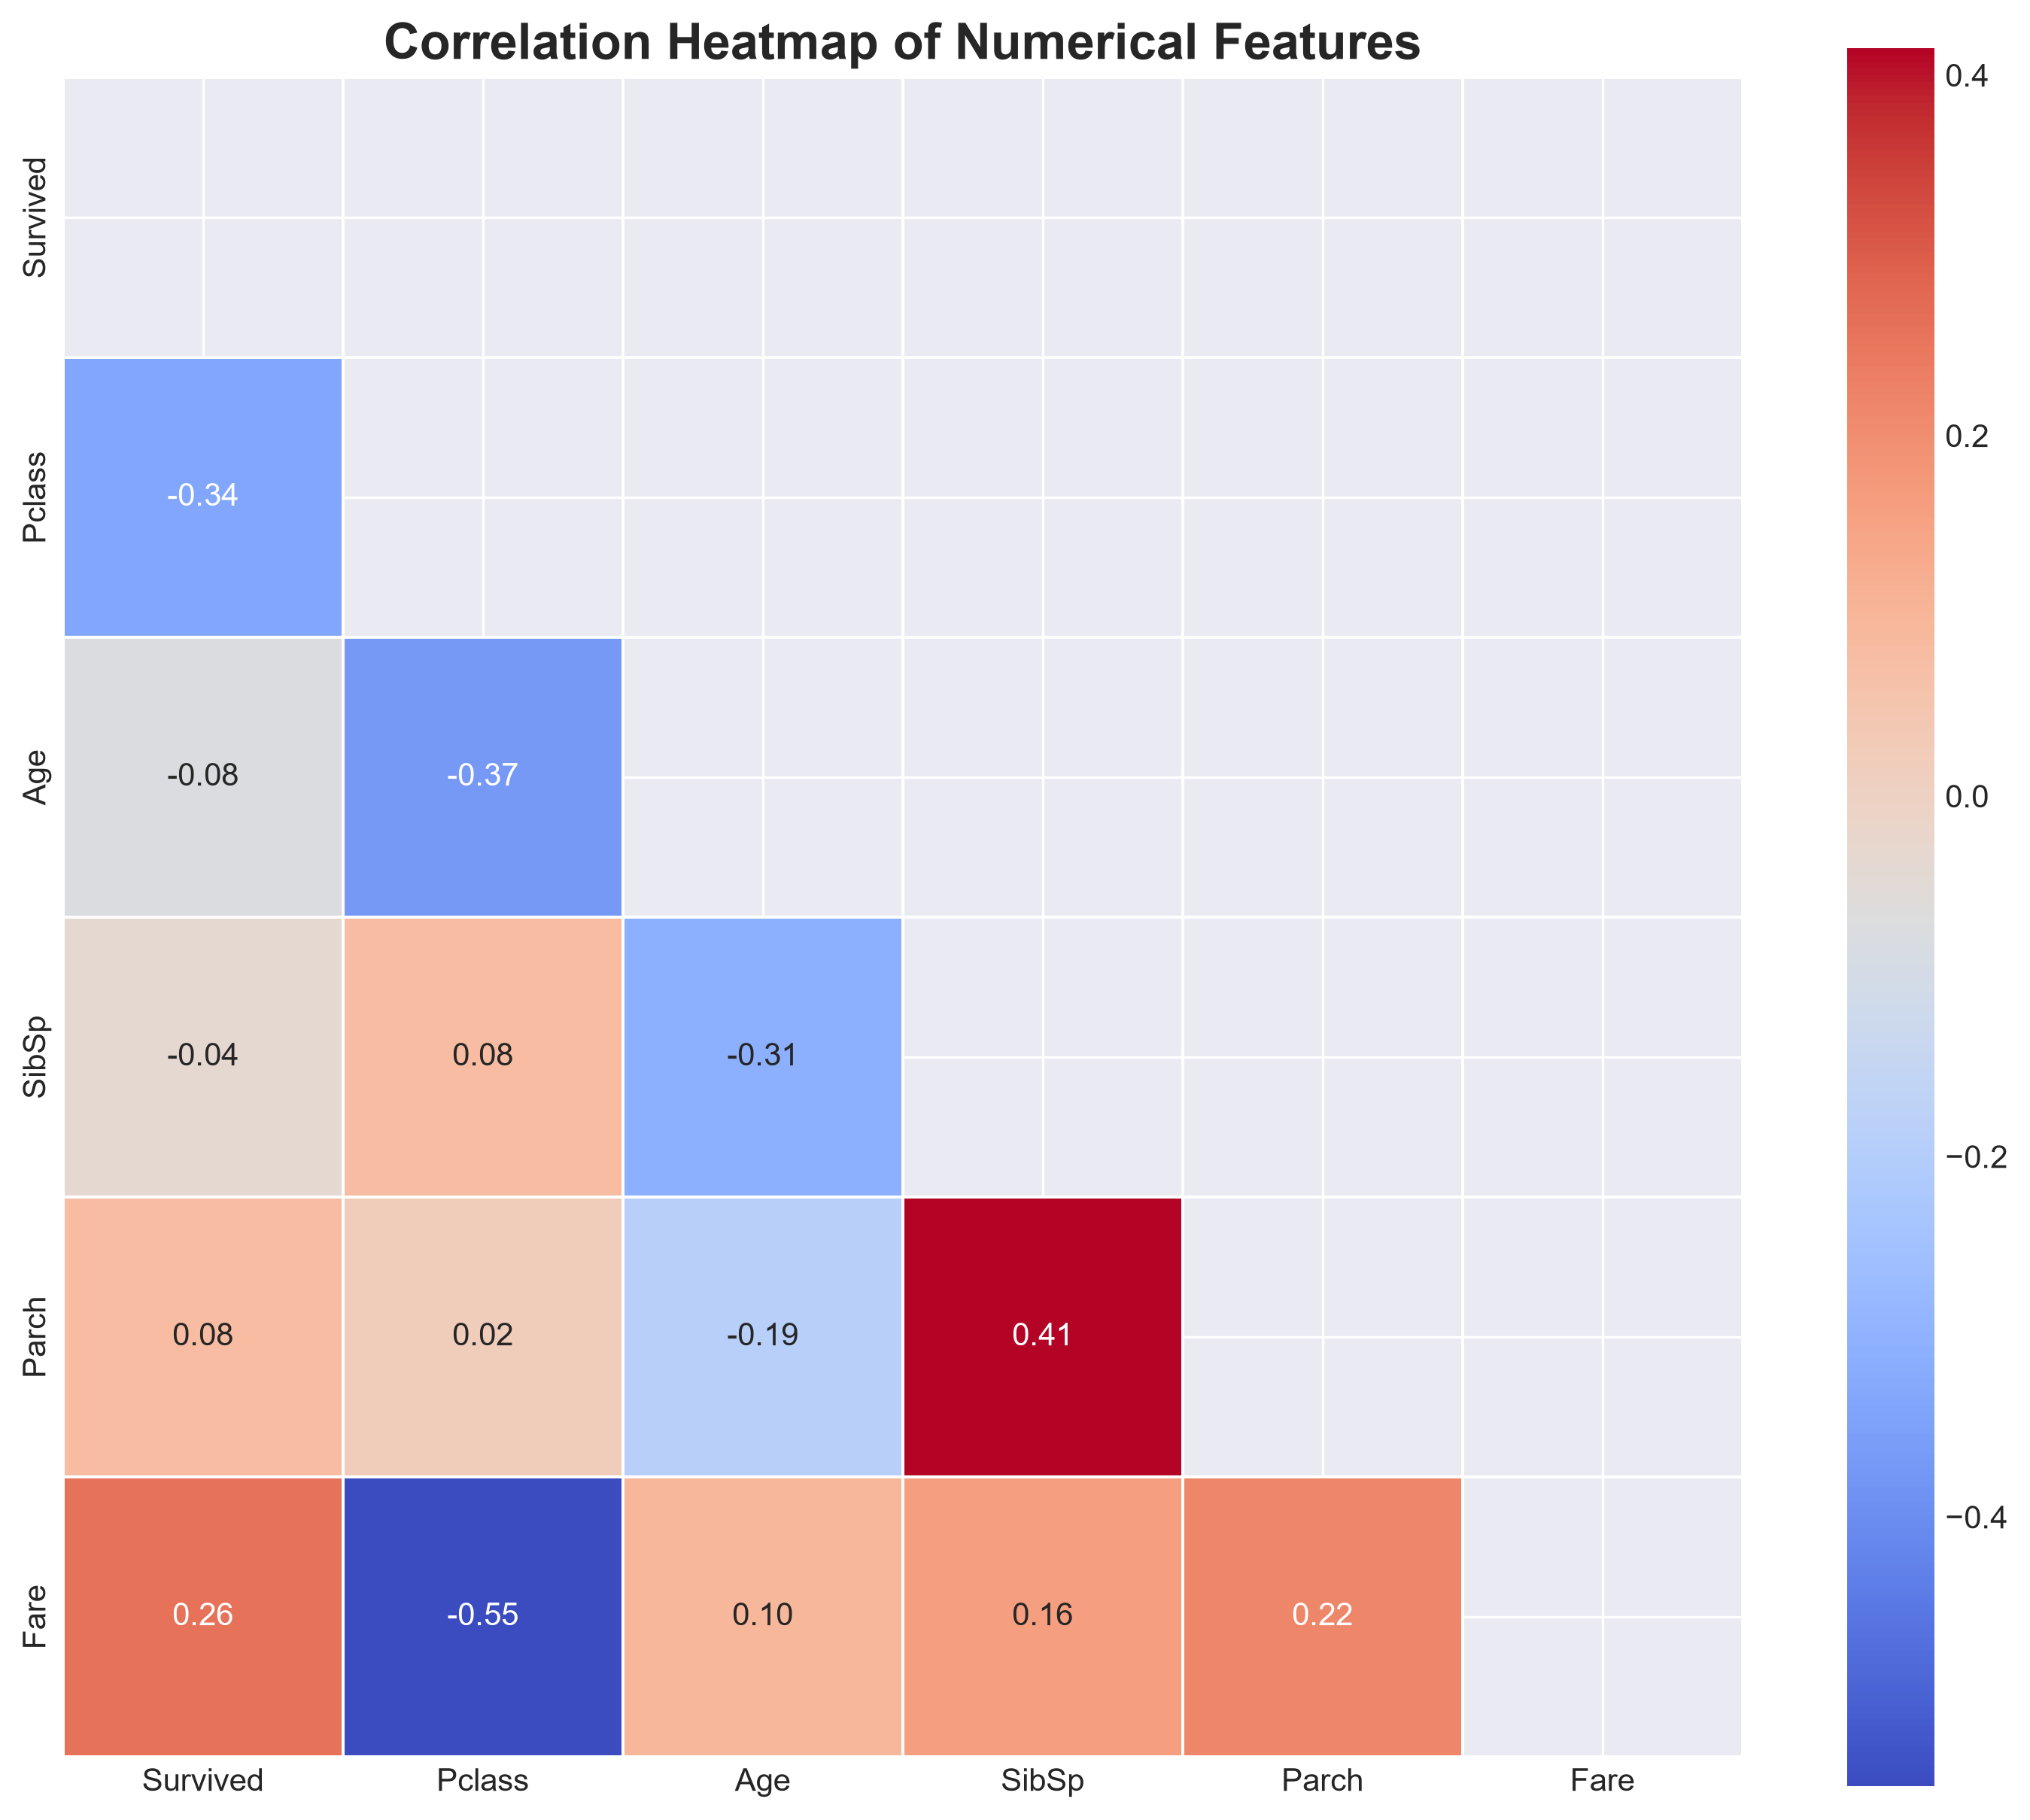

In [153]:
# 2.7 Survival by Embarkation Port
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Embarked', hue='Survived', palette=['#ff6b6b', '#51cf66'])
plt.title('Survival by Embarkation Port', fontsize=16, fontweight='bold')
plt.xlabel('Embarkation Port')
plt.ylabel('Count')
plt.legend(['Not Survived', 'Survived'])
plt.savefig(os.path.join(OUTPUT_DIR, '7_survival_by_embarkation.png'), dpi=300, bbox_inches='tight')
plt.close()

Figure 7_survival_by_embarkation– Cherbourg (C) had higher survival.

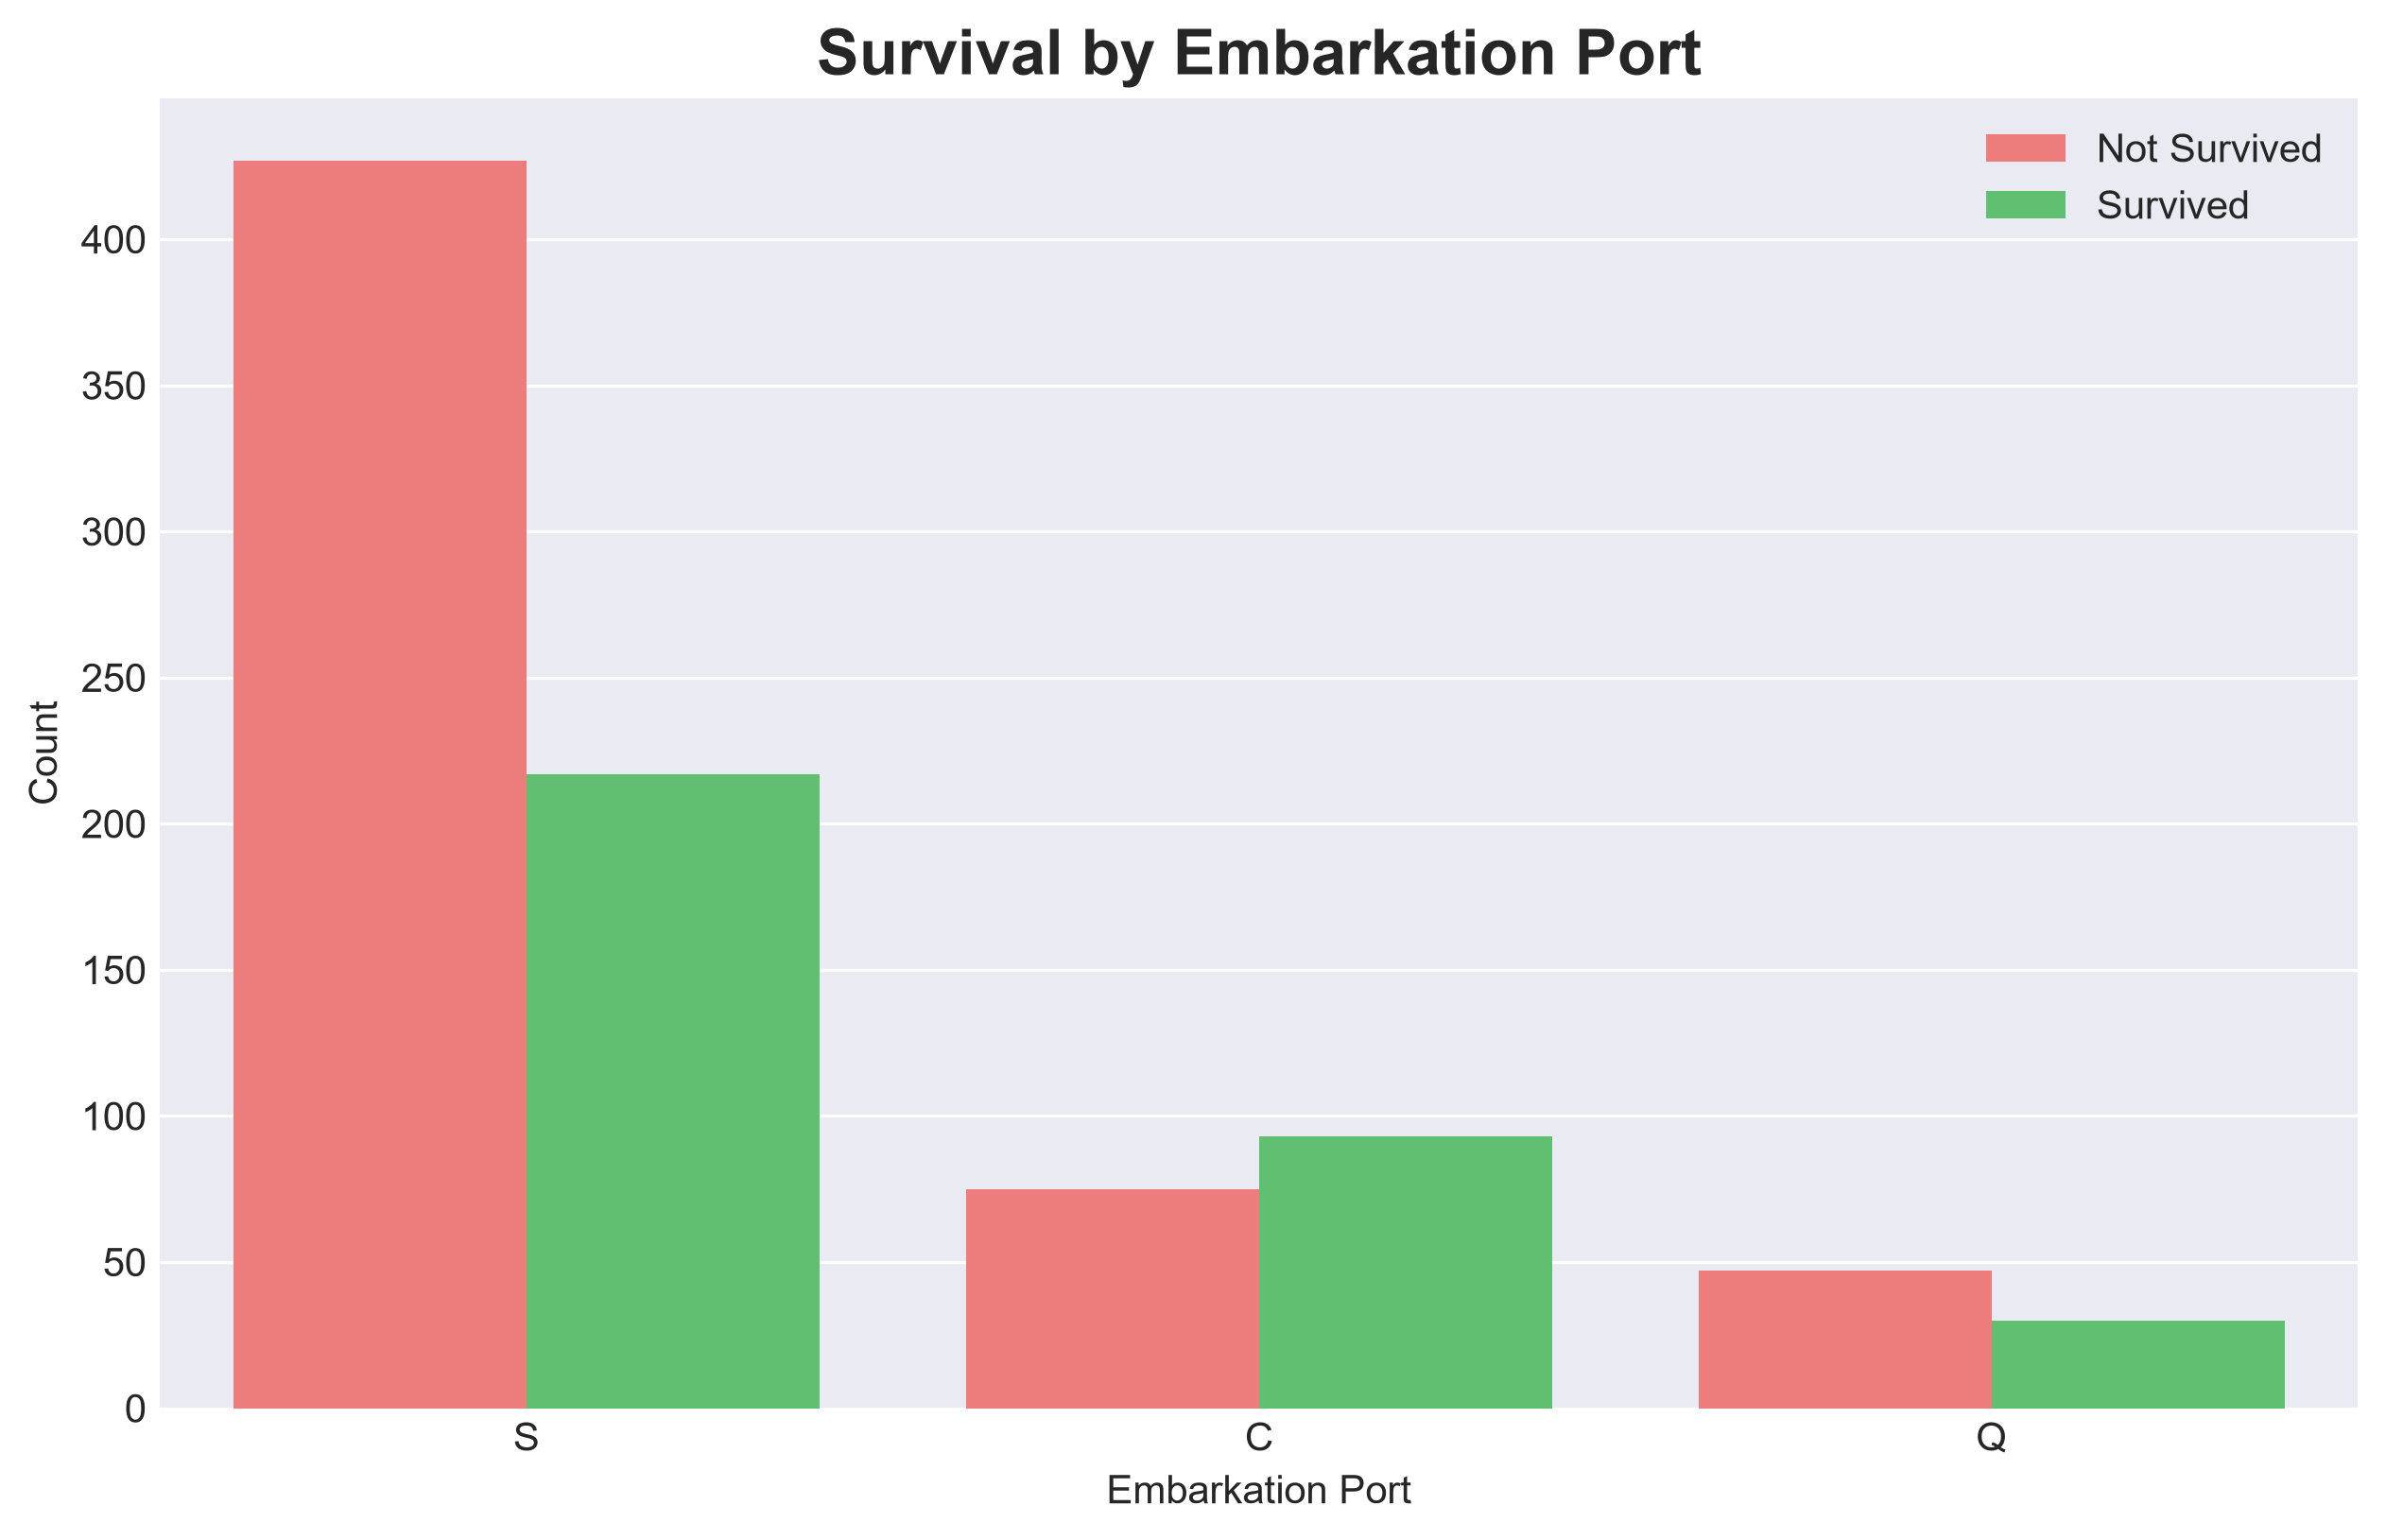

In [154]:
# 2.8 Family Size vs Survival
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='FamilySize', y='Survived', palette='viridis')
plt.title('Survival Rate by Family Size', fontsize=16, fontweight='bold')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.savefig(os.path.join(OUTPUT_DIR, '8_survival_by_family_size.png'), dpi=300, bbox_inches='tight')
plt.close()

Figure 8_survival_by_family_size– survival peaks for size 2–4.

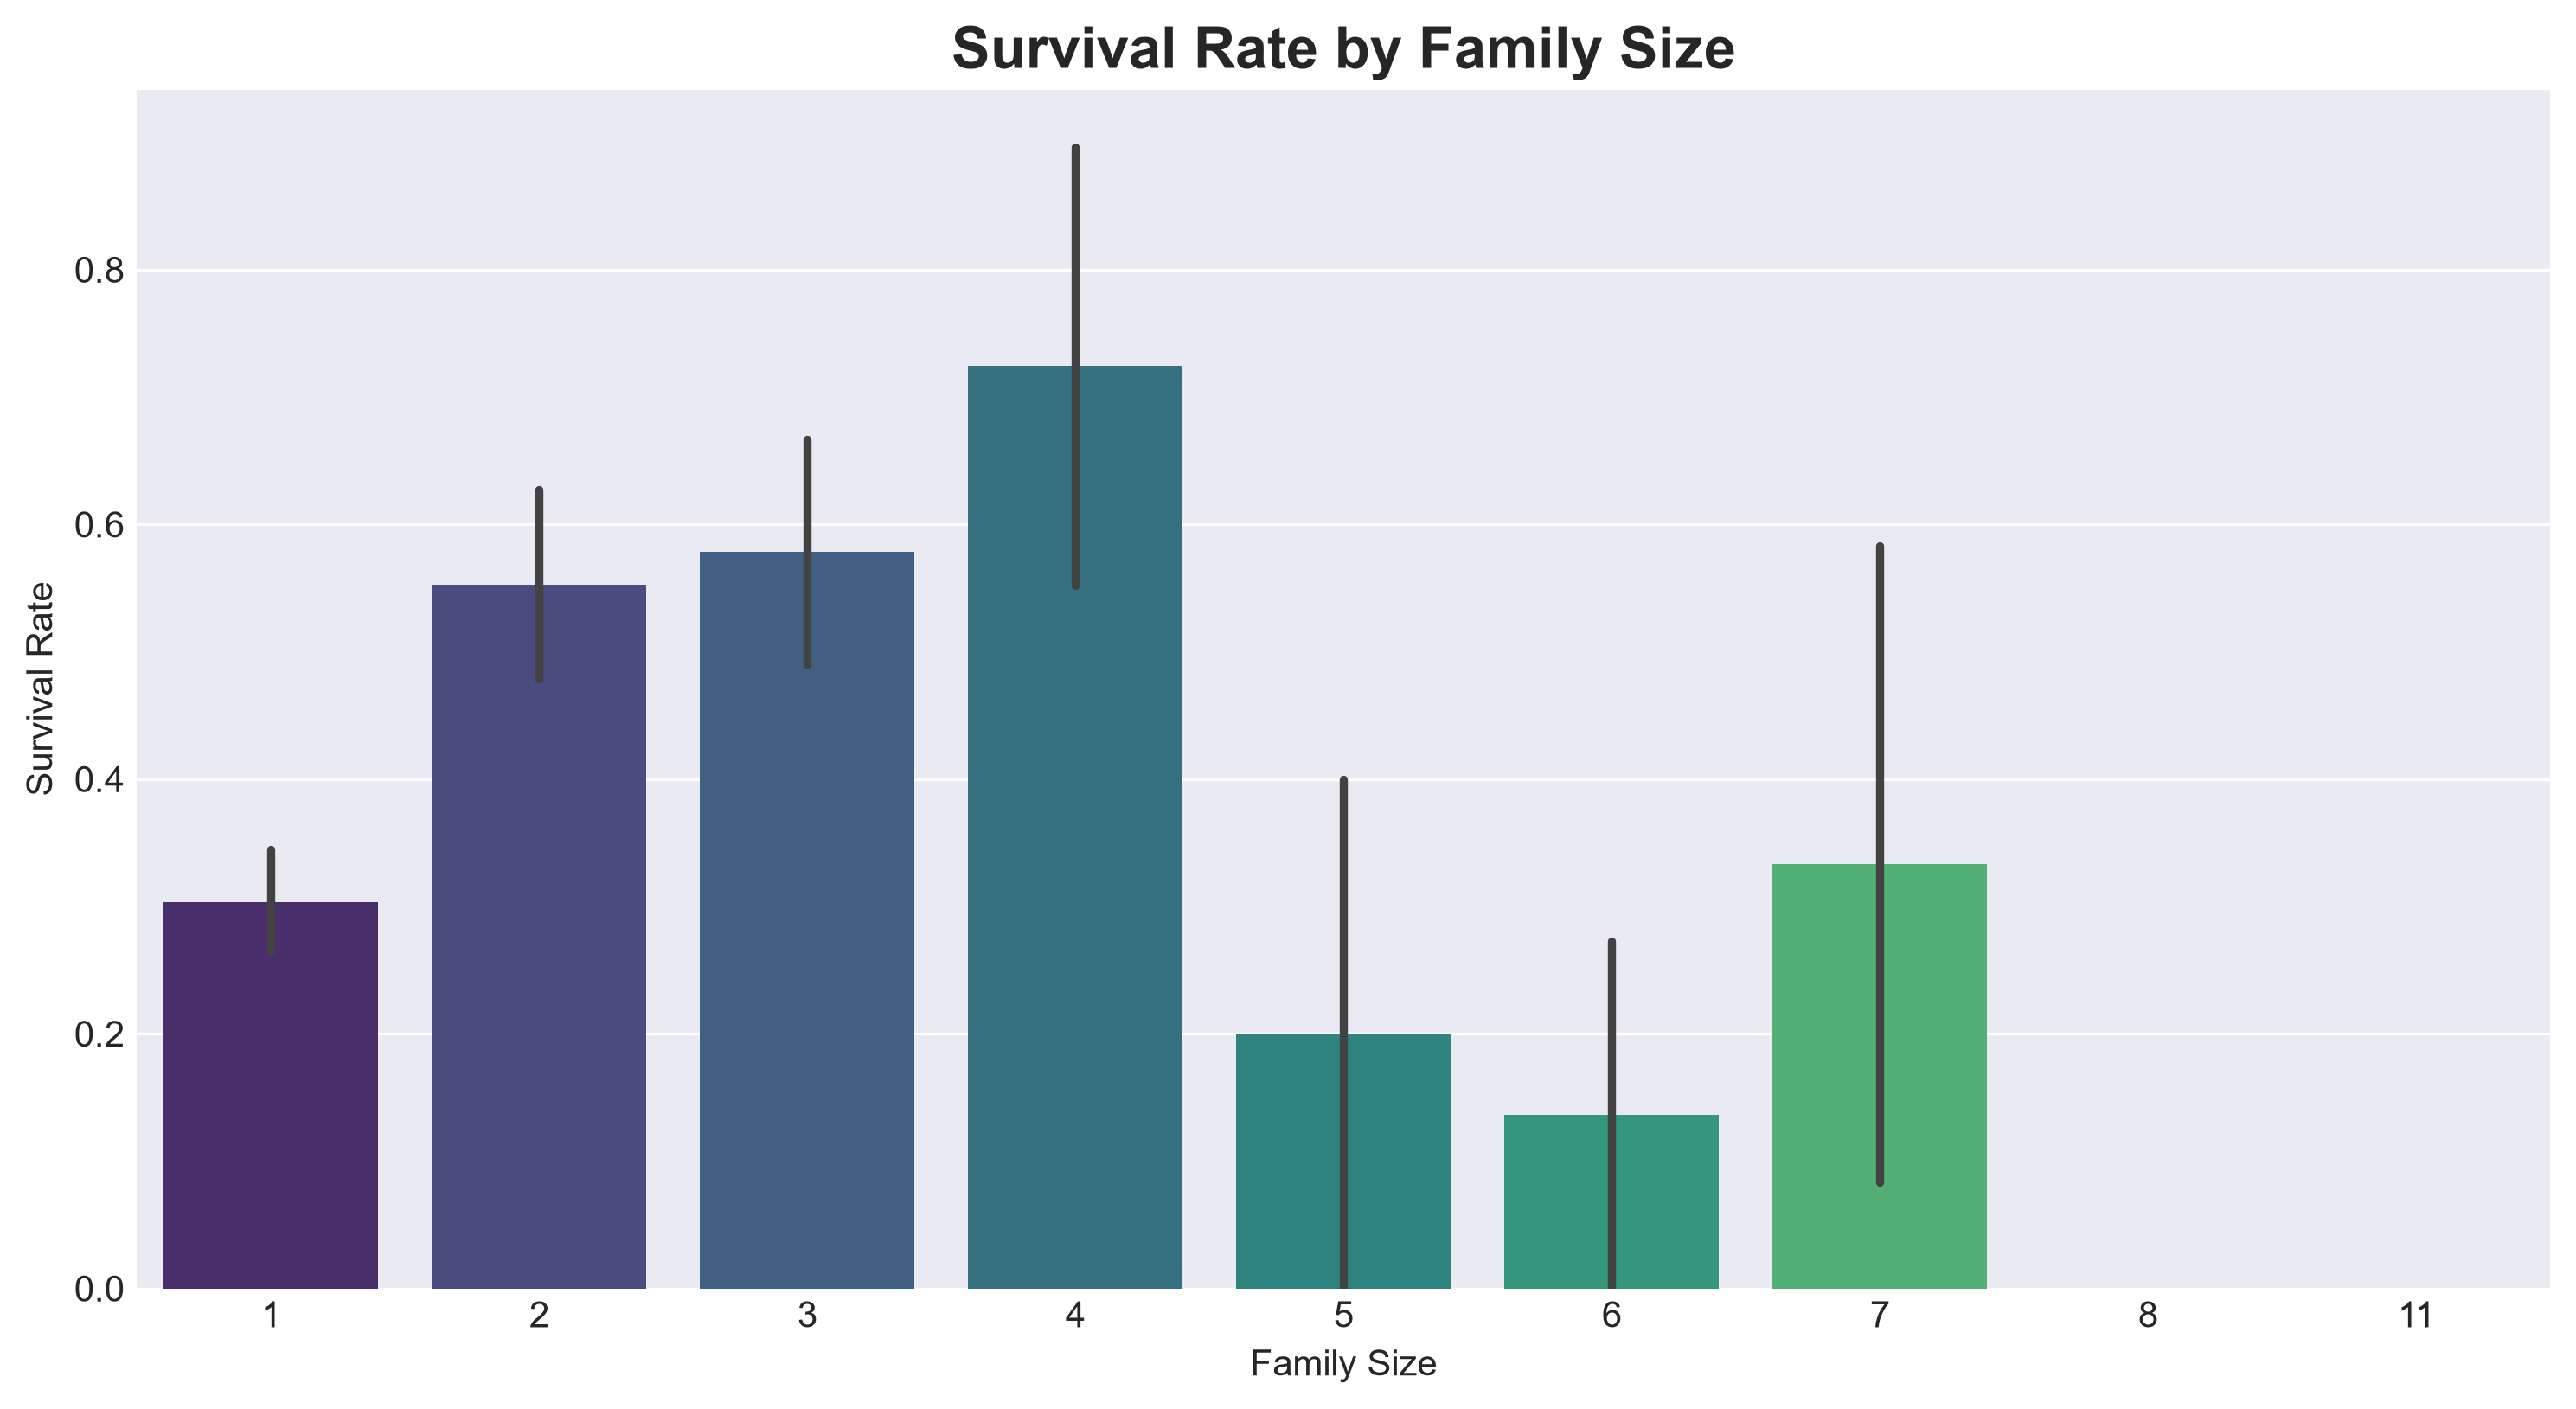

In [155]:
# 2.9 Age Group vs Survival
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], 
                         labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
plt.figure(figsize=(12, 6))
age_survival = df.groupby('AgeGroup')['Survived'].mean()
age_survival.plot(kind='bar', color='steelblue')
plt.title('Survival Rate by Age Group', fontsize=16, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.ylim(0, 1)
for i, v in enumerate(age_survival):
    plt.text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')
plt.savefig(os.path.join(OUTPUT_DIR, '9_survival_by_age_group.png'), dpi=300, bbox_inches='tight')
plt.close()

Figure 9_survival_by_age_group – children have highest survival.

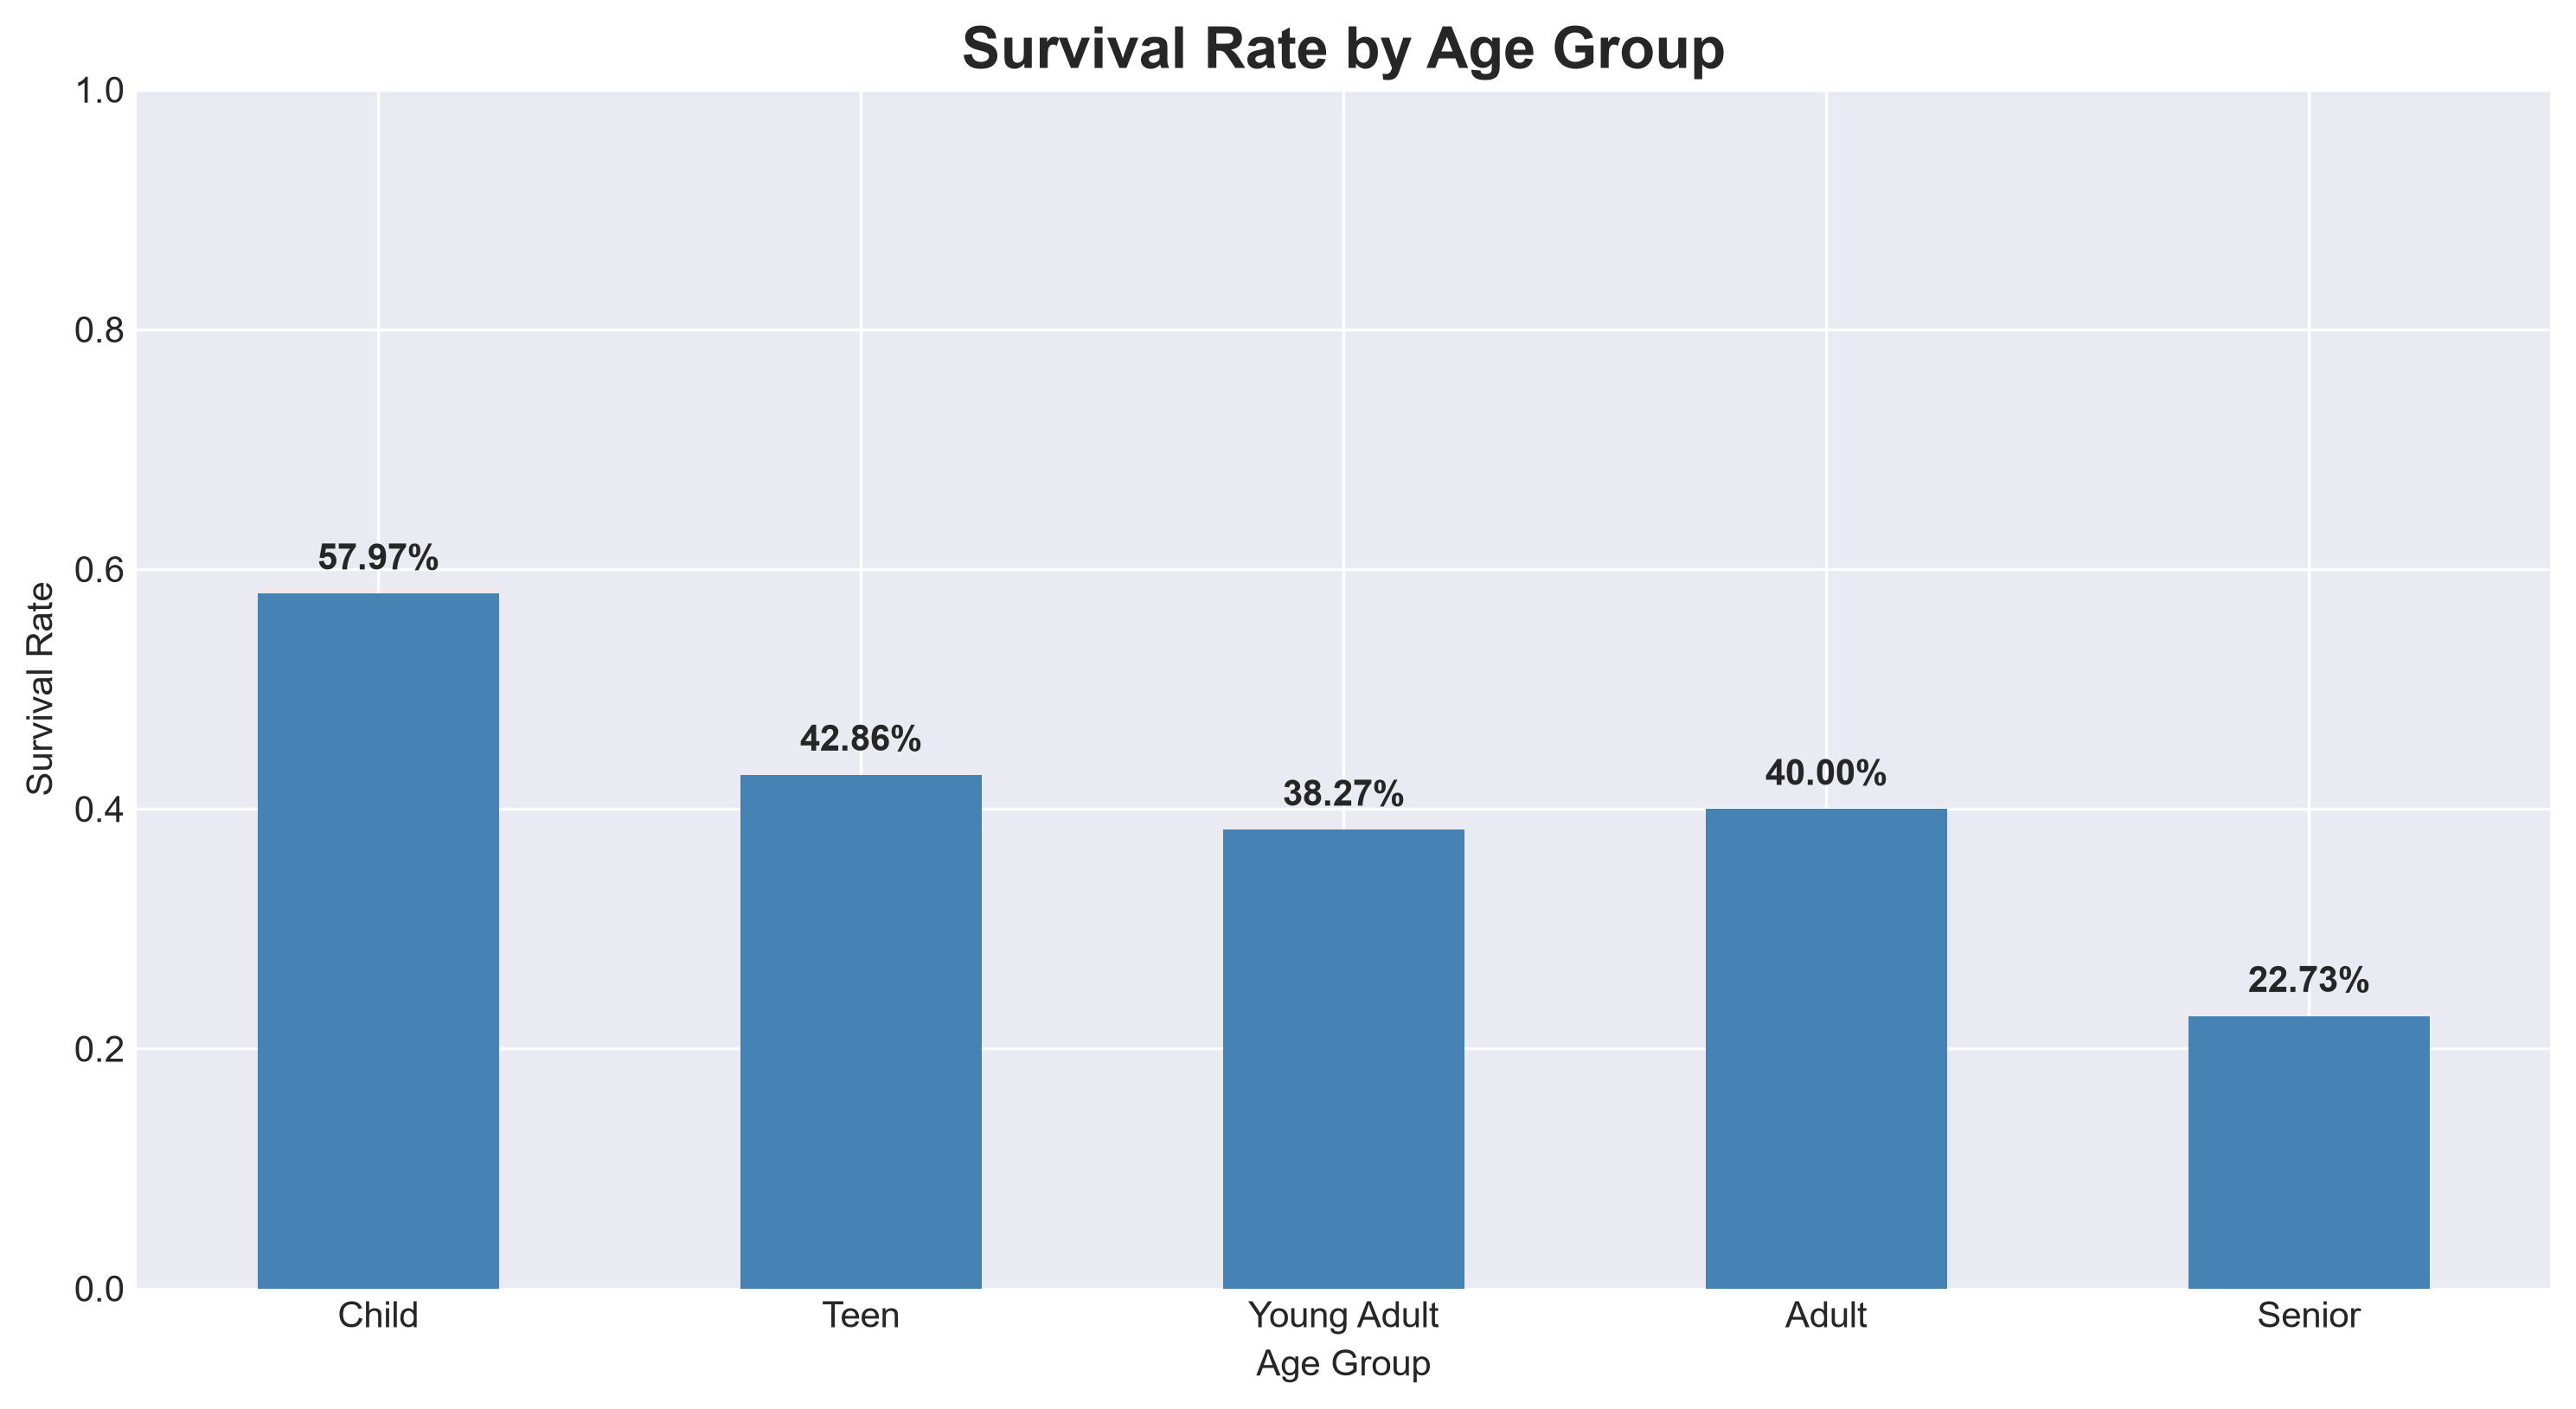

In [156]:
# 2.10 Fare Category vs Survival
df['FareCategory'] = pd.qcut(df['Fare'].fillna(0), q=4, labels=['Low', 'Medium', 'High', 'Very High'])
plt.figure(figsize=(12, 6))
fare_survival = df.groupby('FareCategory')['Survived'].mean()
fare_survival.plot(kind='bar', color='steelblue')
plt.title('Survival Rate by Fare Category', fontsize=16, fontweight='bold')
plt.xlabel('Fare Category')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.ylim(0, 1)
for i, v in enumerate(fare_survival):
    plt.text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')
plt.savefig(os.path.join(OUTPUT_DIR, '10_survival_by_fare_category.png'), dpi=300, bbox_inches='tight')
plt.close()

Figure 10_survival_by_fare_category – higher fare → higher survival.

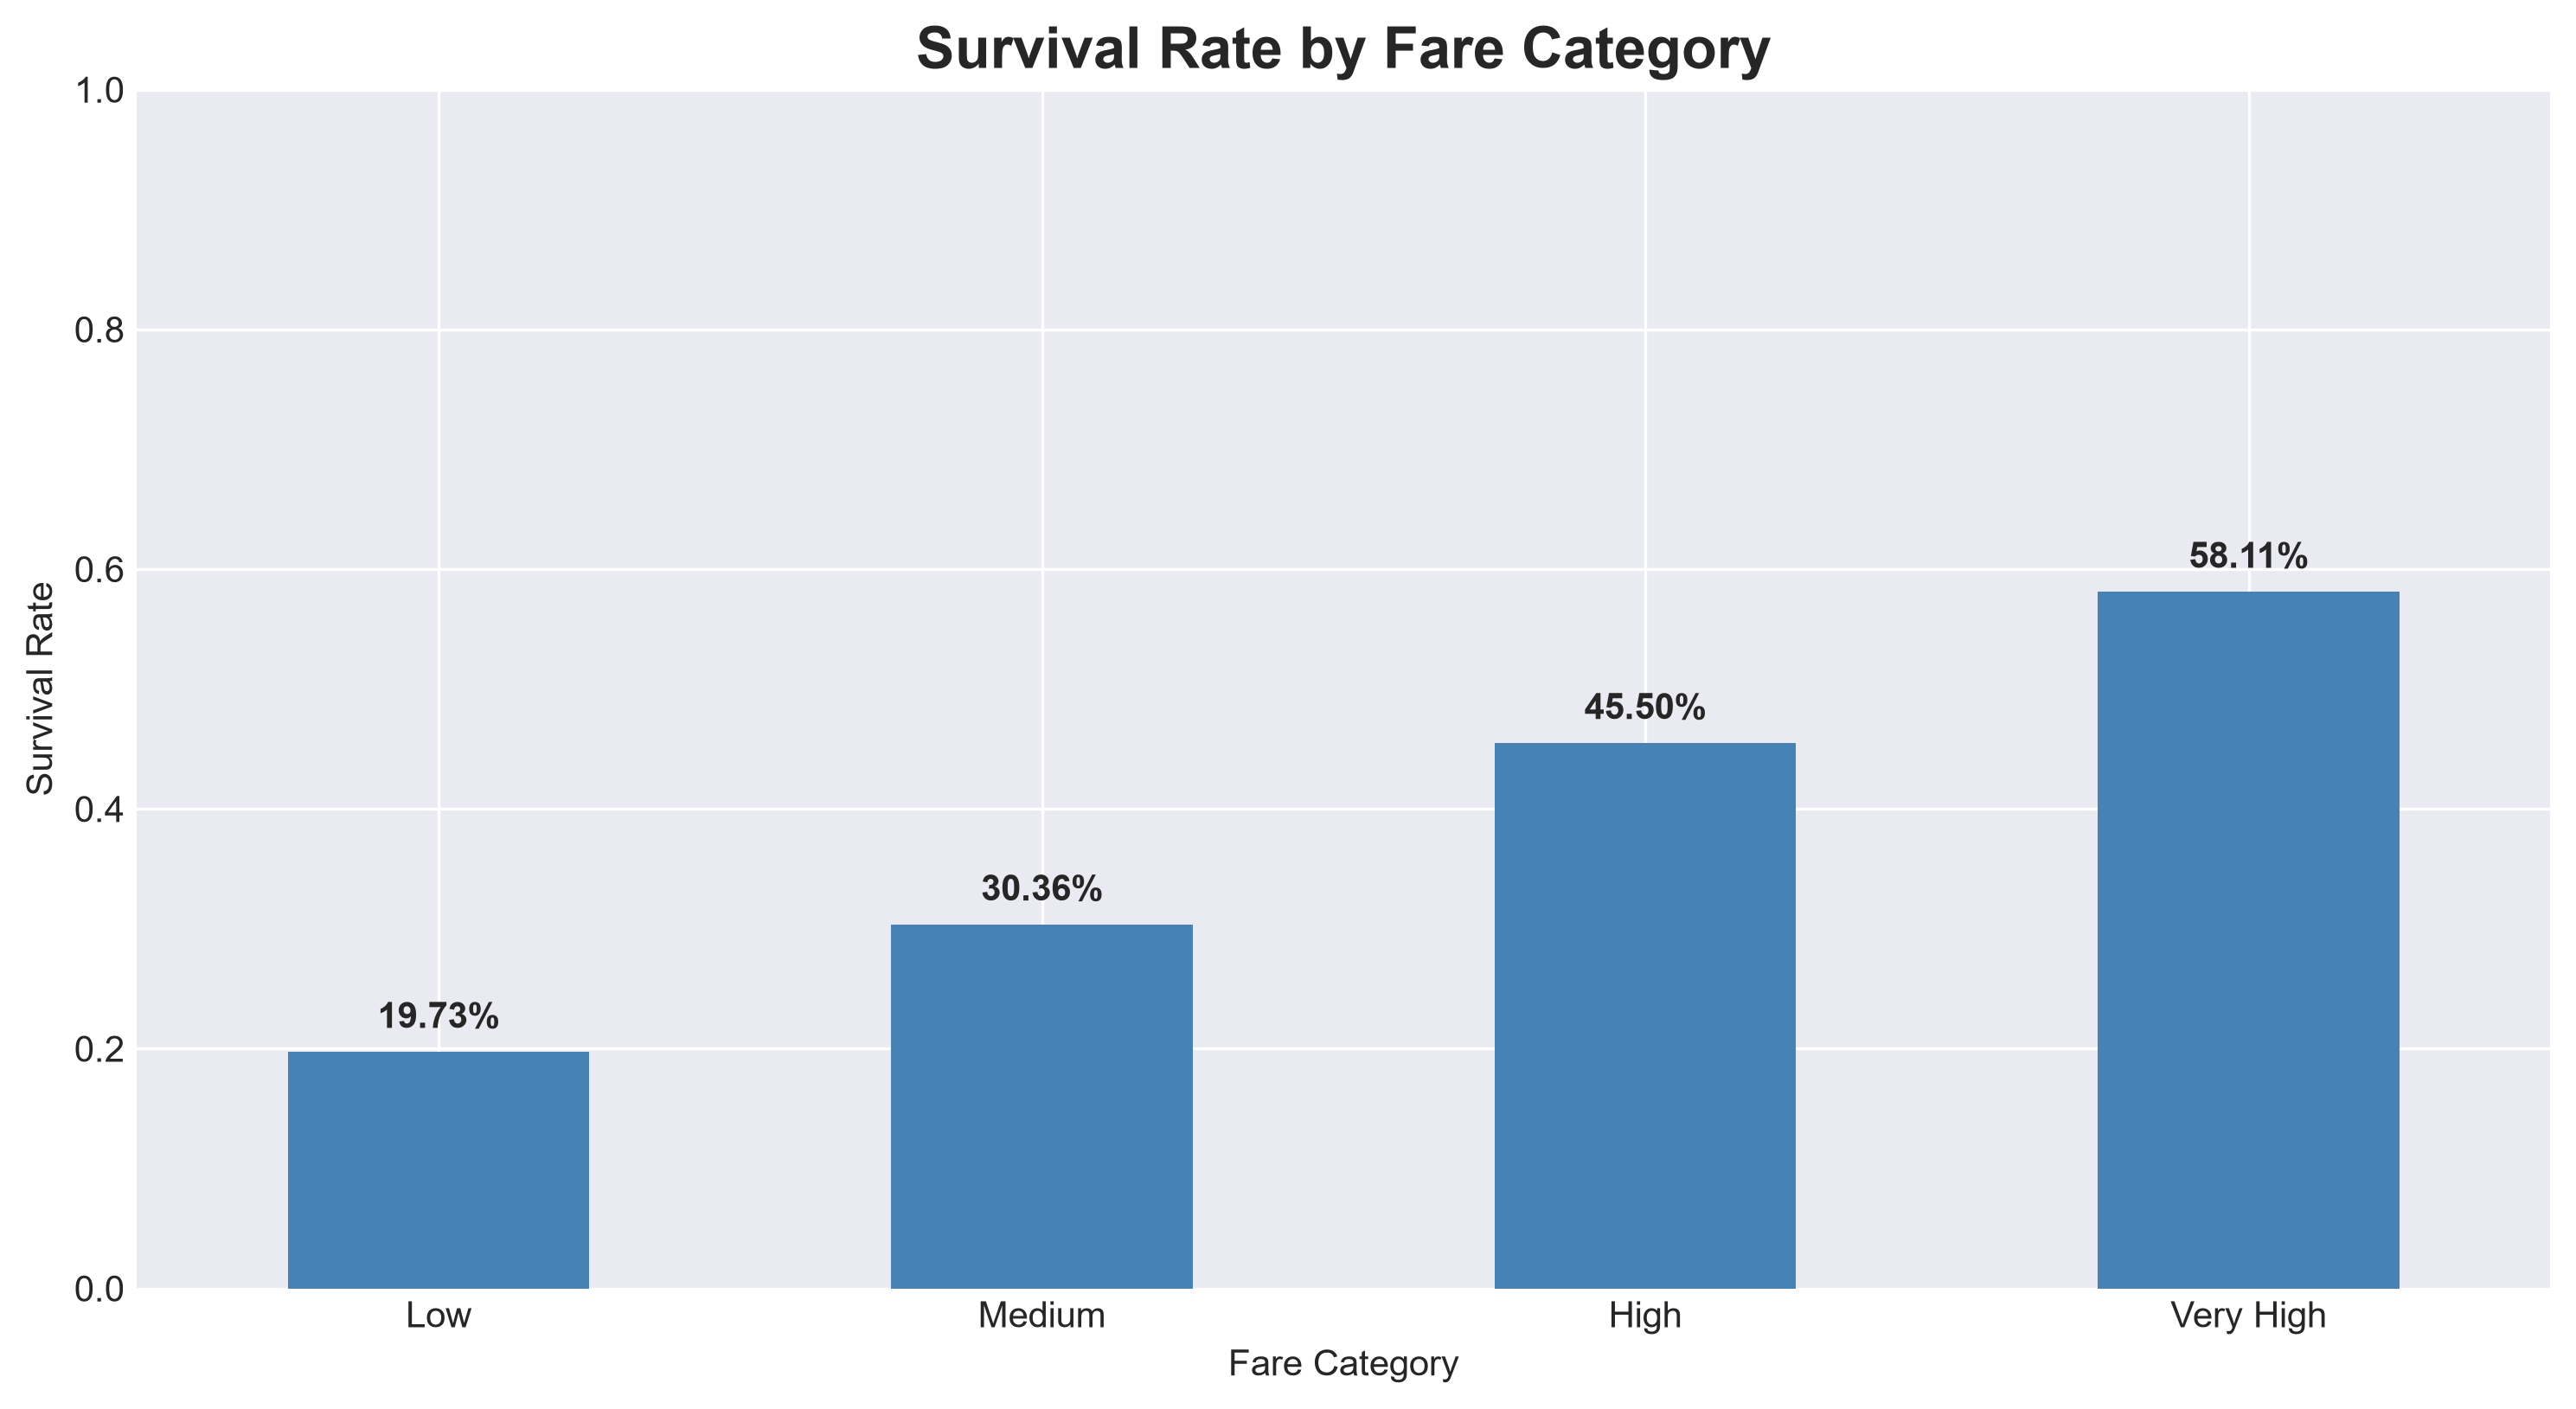

All EDA visualizations saved to output directory!

Step 3: Data Preprocessing

In [157]:
# Create a copy and drop unnecessary columns
df_processed = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'AgeGroup', 'FareCategory'], errors='ignore')
print(f"Columns after dropping: {df_processed.columns.tolist()}")

# Handle missing values
age_median = df_processed['Age'].median()
df_processed['Age'] = df_processed['Age'].fillna(age_median)
embarked_mode = df_processed['Embarked'].mode()[0]
df_processed['Embarked'] = df_processed['Embarked'].fillna(embarked_mode)
fare_median = df_processed['Fare'].median()
df_processed['Fare'] = df_processed['Fare'].fillna(fare_median)
print(f"Age filled with median: {age_median}, Embarked with mode: {embarked_mode}, Fare with median: {fare_median}")
print(f"Remaining missing values: {df_processed.isnull().sum().sum()}")

# Encode categorical variables
le_sex = LabelEncoder()
df_processed['Sex'] = le_sex.fit_transform(df_processed['Sex'])
le_embarked = LabelEncoder()
df_processed['Embarked'] = le_embarked.fit_transform(df_processed['Embarked'])

# Create additional features
df_processed['FamilySize'] = df_processed['SibSp'] + df_processed['Parch'] + 1
df_processed['IsAlone'] = (df_processed['FamilySize'] == 1).astype(int)
df_processed['Age*Class'] = df_processed['Age'] * df_processed['Pclass']

print("Additional features created:")
print(df_processed[['FamilySize', 'IsAlone', 'Age*Class']].head())

Columns after dropping: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'FamilySize']
Age filled with median: 28.0, Embarked with mode: S, Fare with median: 14.4542
Remaining missing values: 690
Additional features created:
   FamilySize  IsAlone  Age*Class
0           2        0       66.0
1           2        0       38.0
2           1        1       78.0
3           2        0       35.0
4           1        1      105.0


Columns after dropping: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Age filled with median: 28.0, Embarked with mode: S, Fare with median: 14.4542
Remaining missing values: 0
Additional features created:
   FamilySize  IsAlone  Age*Class
0           2        0       63.0
1           2        0       38.0
2           2        0       76.0
3           2        0       71.0
4           2        0       66.0

Step 4: Split Data into Features and Target

In [158]:
X = df_processed.drop('Survived', axis=1)
y = df_processed['Survived']
print(f"Features: {X.columns.tolist()}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")

# Scale numerical features
scaler = StandardScaler()
numeric_features = ['Age', 'Fare', 'FamilySize', 'Age*Class']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])
print(f"NaN in scaled sets: Train={X_train_scaled.isnull().sum().sum()}, Test={X_test_scaled.isnull().sum().sum()}")

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone', 'FamilySize', 'IsAlone', 'Age*Class']
Training set: 712 samples, Test set: 179 samples
NaN in scaled sets: Train=555, Test=135


Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Age*Class']
Training set: 712 samples, Test set: 179 samples
NaN in scaled sets: Train=0, Test=0

Step 5: Model Training and Evaluation

In [159]:
import seaborn as sns
df = sns.load_dataset('titanic')
# Rename columns to match the original script
df.rename(columns={
    'survived': 'Survived',
    'pclass': 'Pclass',
    'sex': 'Sex',
    'age': 'Age',
    'sibsp': 'SibSp',
    'parch': 'Parch',
    'fare': 'Fare',
    'embarked': 'Embarked'
}, inplace=True)

Logistic Regression:
  Accuracy: 0.7933
  ROC AUC: 0.8504
  CV Mean: 0.7992 (+/- 0.0274)
              precision    recall  f1-score   support

Not Survived       0.82      0.84      0.83       110
    Survived       0.75      0.72      0.74        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

Random Forest:
  Accuracy: 0.8268
  ROC AUC: 0.8745
  CV Mean: 0.8248 (+/- 0.0367)
              precision    recall  f1-score   support

Not Survived       0.84      0.86      0.85       110
    Survived       0.80      0.77      0.78        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179

Gradient Boosting:
  Accuracy: 0.8268
  ROC AUC: 0.8723
  CV Mean: 0.8229 (+/- 0.0288)
              precision    recall  f1-score   support

Not Survived       0.84      0.87      0.86       110
    Survived       0.80      0.75      0.78        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179

SVM:
  Accuracy: 0.8101
  ROC AUC: 0.8413
  CV Mean: 0.8155 (+/- 0.0301)
              precision    recall  f1-score   support

Not Survived       0.83      0.86      0.84       110
    Survived       0.78      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179

Step 6: Model Comparison Visualizations

In [160]:
# 1. Ensure all features are numeric
for col in X_train_scaled.columns:
    if X_train_scaled[col].dtype == 'object' or pd.api.types.is_string_dtype(X_train_scaled[col]):
        print(f"   Converting '{col}' to numeric...")
        X_train_scaled[col] = pd.to_numeric(X_train_scaled[col], errors='coerce').fillna(0)
        X_test_scaled[col] = pd.to_numeric(X_test_scaled[col], errors='coerce').fillna(0)
    if not np.issubdtype(X_train_scaled[col].dtype, np.number):
        X_train_scaled[col] = X_train_scaled[col].astype(float)
        X_test_scaled[col] = X_test_scaled[col].astype(float)

# 2. Re‑train models if 'results' is missing
try:
    results
except NameError:
    print("\n'results' missing – re‑training models...")
    # Define models if needed
    try:
        models
    except NameError:
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
        from sklearn.svm import SVC
        models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
            'SVM': SVC(probability=True, random_state=42)
        }
    results = {}
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        accuracy = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
        results[name] = {
            'Accuracy': accuracy,
            'ROC AUC': roc_auc,
            'CV Mean': cv_scores.mean(),
            'CV Std': cv_scores.std()
        }
    print("Training complete.")

#  3. Generate ONLY the bar chart 
plt.figure(figsize=(12, 6))
metrics = ['Accuracy', 'ROC AUC', 'CV Mean']
x = np.arange(len(metrics))
width = 0.2
colors_models = ['#ff6b6b', '#51cf66', '#4dabf7', '#fcc419']

for i, (model_name, scores) in enumerate(results.items()):
    values = [scores[metric] for metric in metrics]
    plt.bar(x + i*width, values, width, label=model_name, color=colors_models[i])

plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.xticks(x + width*1.5, metrics)
plt.legend(loc='lower right')
plt.ylim(0.7, 1.0)

# Add value labels
for i, (model_name, scores) in enumerate(results.items()):
    values = [scores[metric] for metric in metrics]
    for j, v in enumerate(values):
        plt.text(j + i*width, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.savefig(os.path.join(OUTPUT_DIR, '11_model_performance_comparison.png'), dpi=300, bbox_inches='tight')
plt.close()

   Converting 'class' to numeric...
   Converting 'who' to numeric...
   Converting 'deck' to numeric...
   Converting 'embark_town' to numeric...
   Converting 'alive' to numeric...


Figure 11_model_performance_comparison

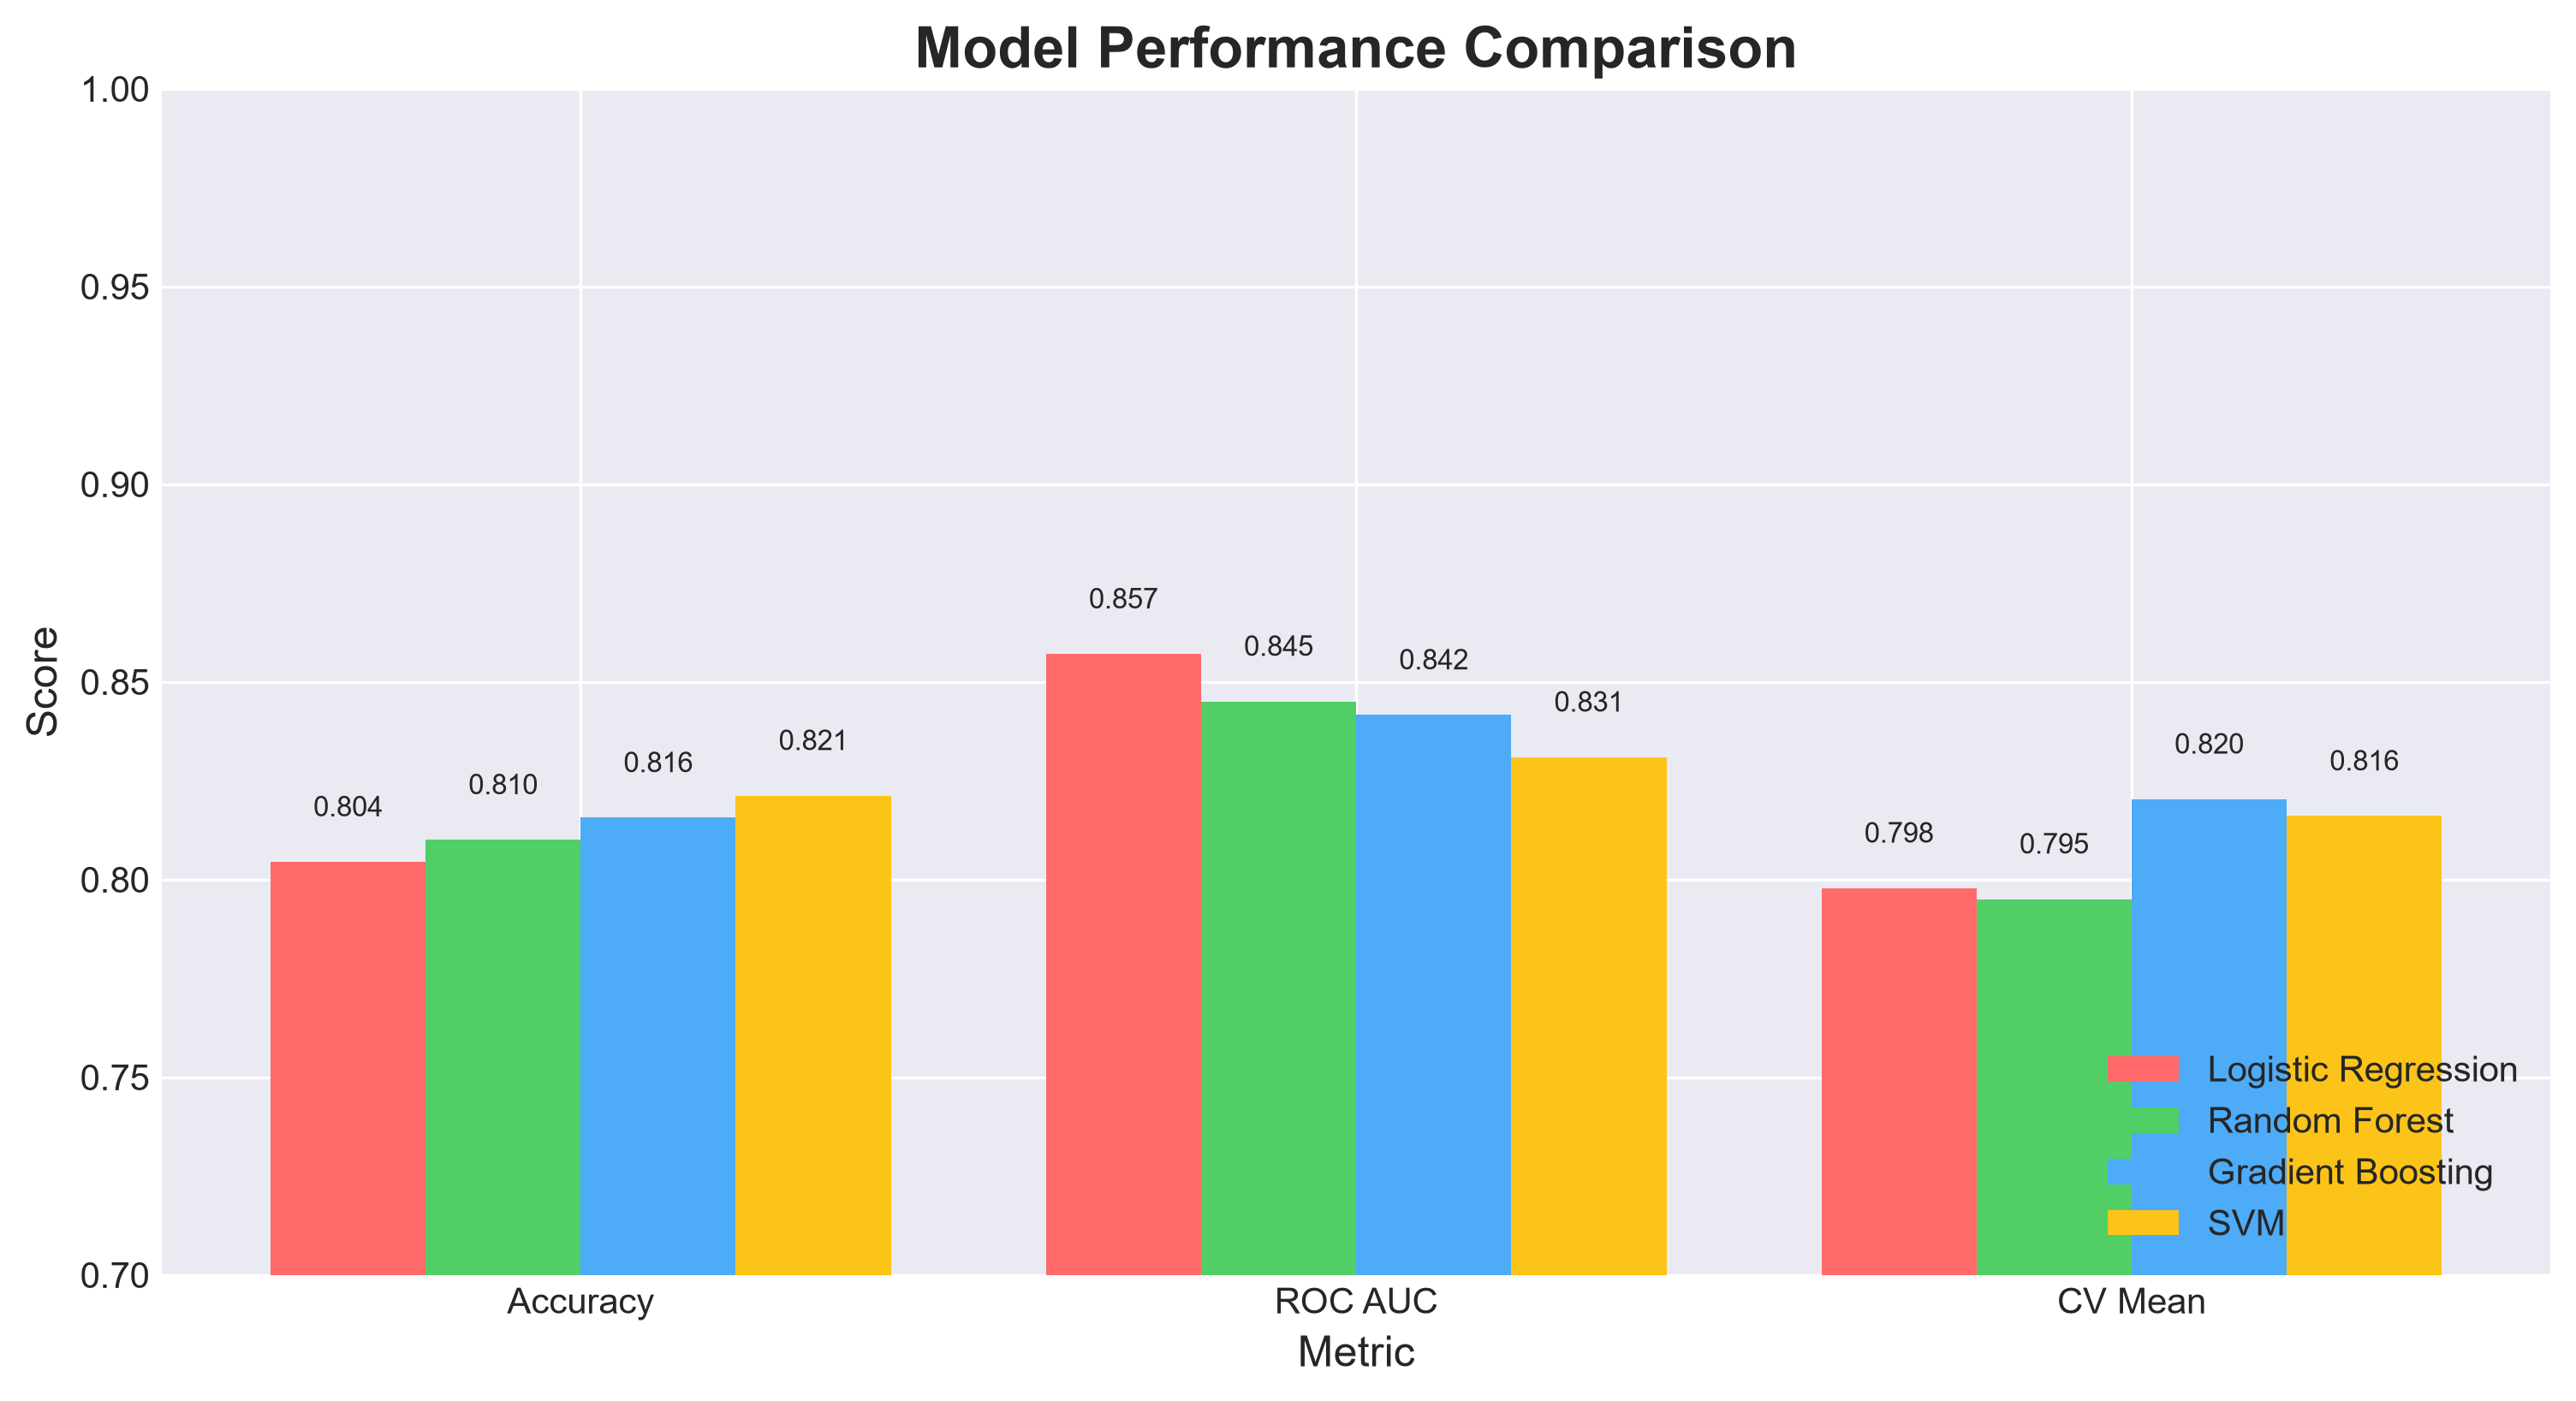

In [161]:
# 1. Ensure all features are numeric
for col in X_train_scaled.columns:
    if X_train_scaled[col].dtype == 'object' or pd.api.types.is_string_dtype(X_train_scaled[col]):
        print(f"   Converting '{col}' to numeric...")
        X_train_scaled[col] = pd.to_numeric(X_train_scaled[col], errors='coerce').fillna(0)
        X_test_scaled[col] = pd.to_numeric(X_test_scaled[col], errors='coerce').fillna(0)
    if not np.issubdtype(X_train_scaled[col].dtype, np.number):
        X_train_scaled[col] = X_train_scaled[col].astype(float)
        X_test_scaled[col] = X_test_scaled[col].astype(float)

# 2. Re‑train models if 'results' is missing
try:
    results
except NameError:
    print("\n'results' missing – re‑training models...")
    try:
        models
    except NameError:
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
        from sklearn.svm import SVC
        models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
            'SVM': SVC(probability=True, random_state=42)
        }
    results = {}
    predictions = {}   # <--- added so confusion matrices can use it
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        accuracy = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
        results[name] = {
            'Accuracy': accuracy,
            'ROC AUC': roc_auc,
            'CV Mean': cv_scores.mean(),
            'CV Std': cv_scores.std()
        }
        predictions[name] = y_pred   # <--- store for later
    print("Training complete.")

# 3. Generate ONLY the bar chart
plt.figure(figsize=(12, 6))
metrics = ['Accuracy', 'ROC AUC', 'CV Mean']
x = np.arange(len(metrics))
width = 0.2
colors_models = ['#ff6b6b', '#51cf66', '#4dabf7', '#fcc419']

for i, (model_name, scores) in enumerate(results.items()):
    values = [scores[metric] for metric in metrics]
    plt.bar(x + i*width, values, width, label=model_name, color=colors_models[i])

plt.xlabel('Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.xticks(x + width*1.5, metrics)
plt.legend(loc='lower right')
plt.ylim(0.7, 1.0)

for i, (model_name, scores) in enumerate(results.items()):
    values = [scores[metric] for metric in metrics]
    for j, v in enumerate(values):
        plt.text(j + i*width, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.savefig(os.path.join(OUTPUT_DIR, '11_model_performance_comparison.png'), dpi=300, bbox_inches='tight')
plt.close()

Figure 12_confusion_matrices

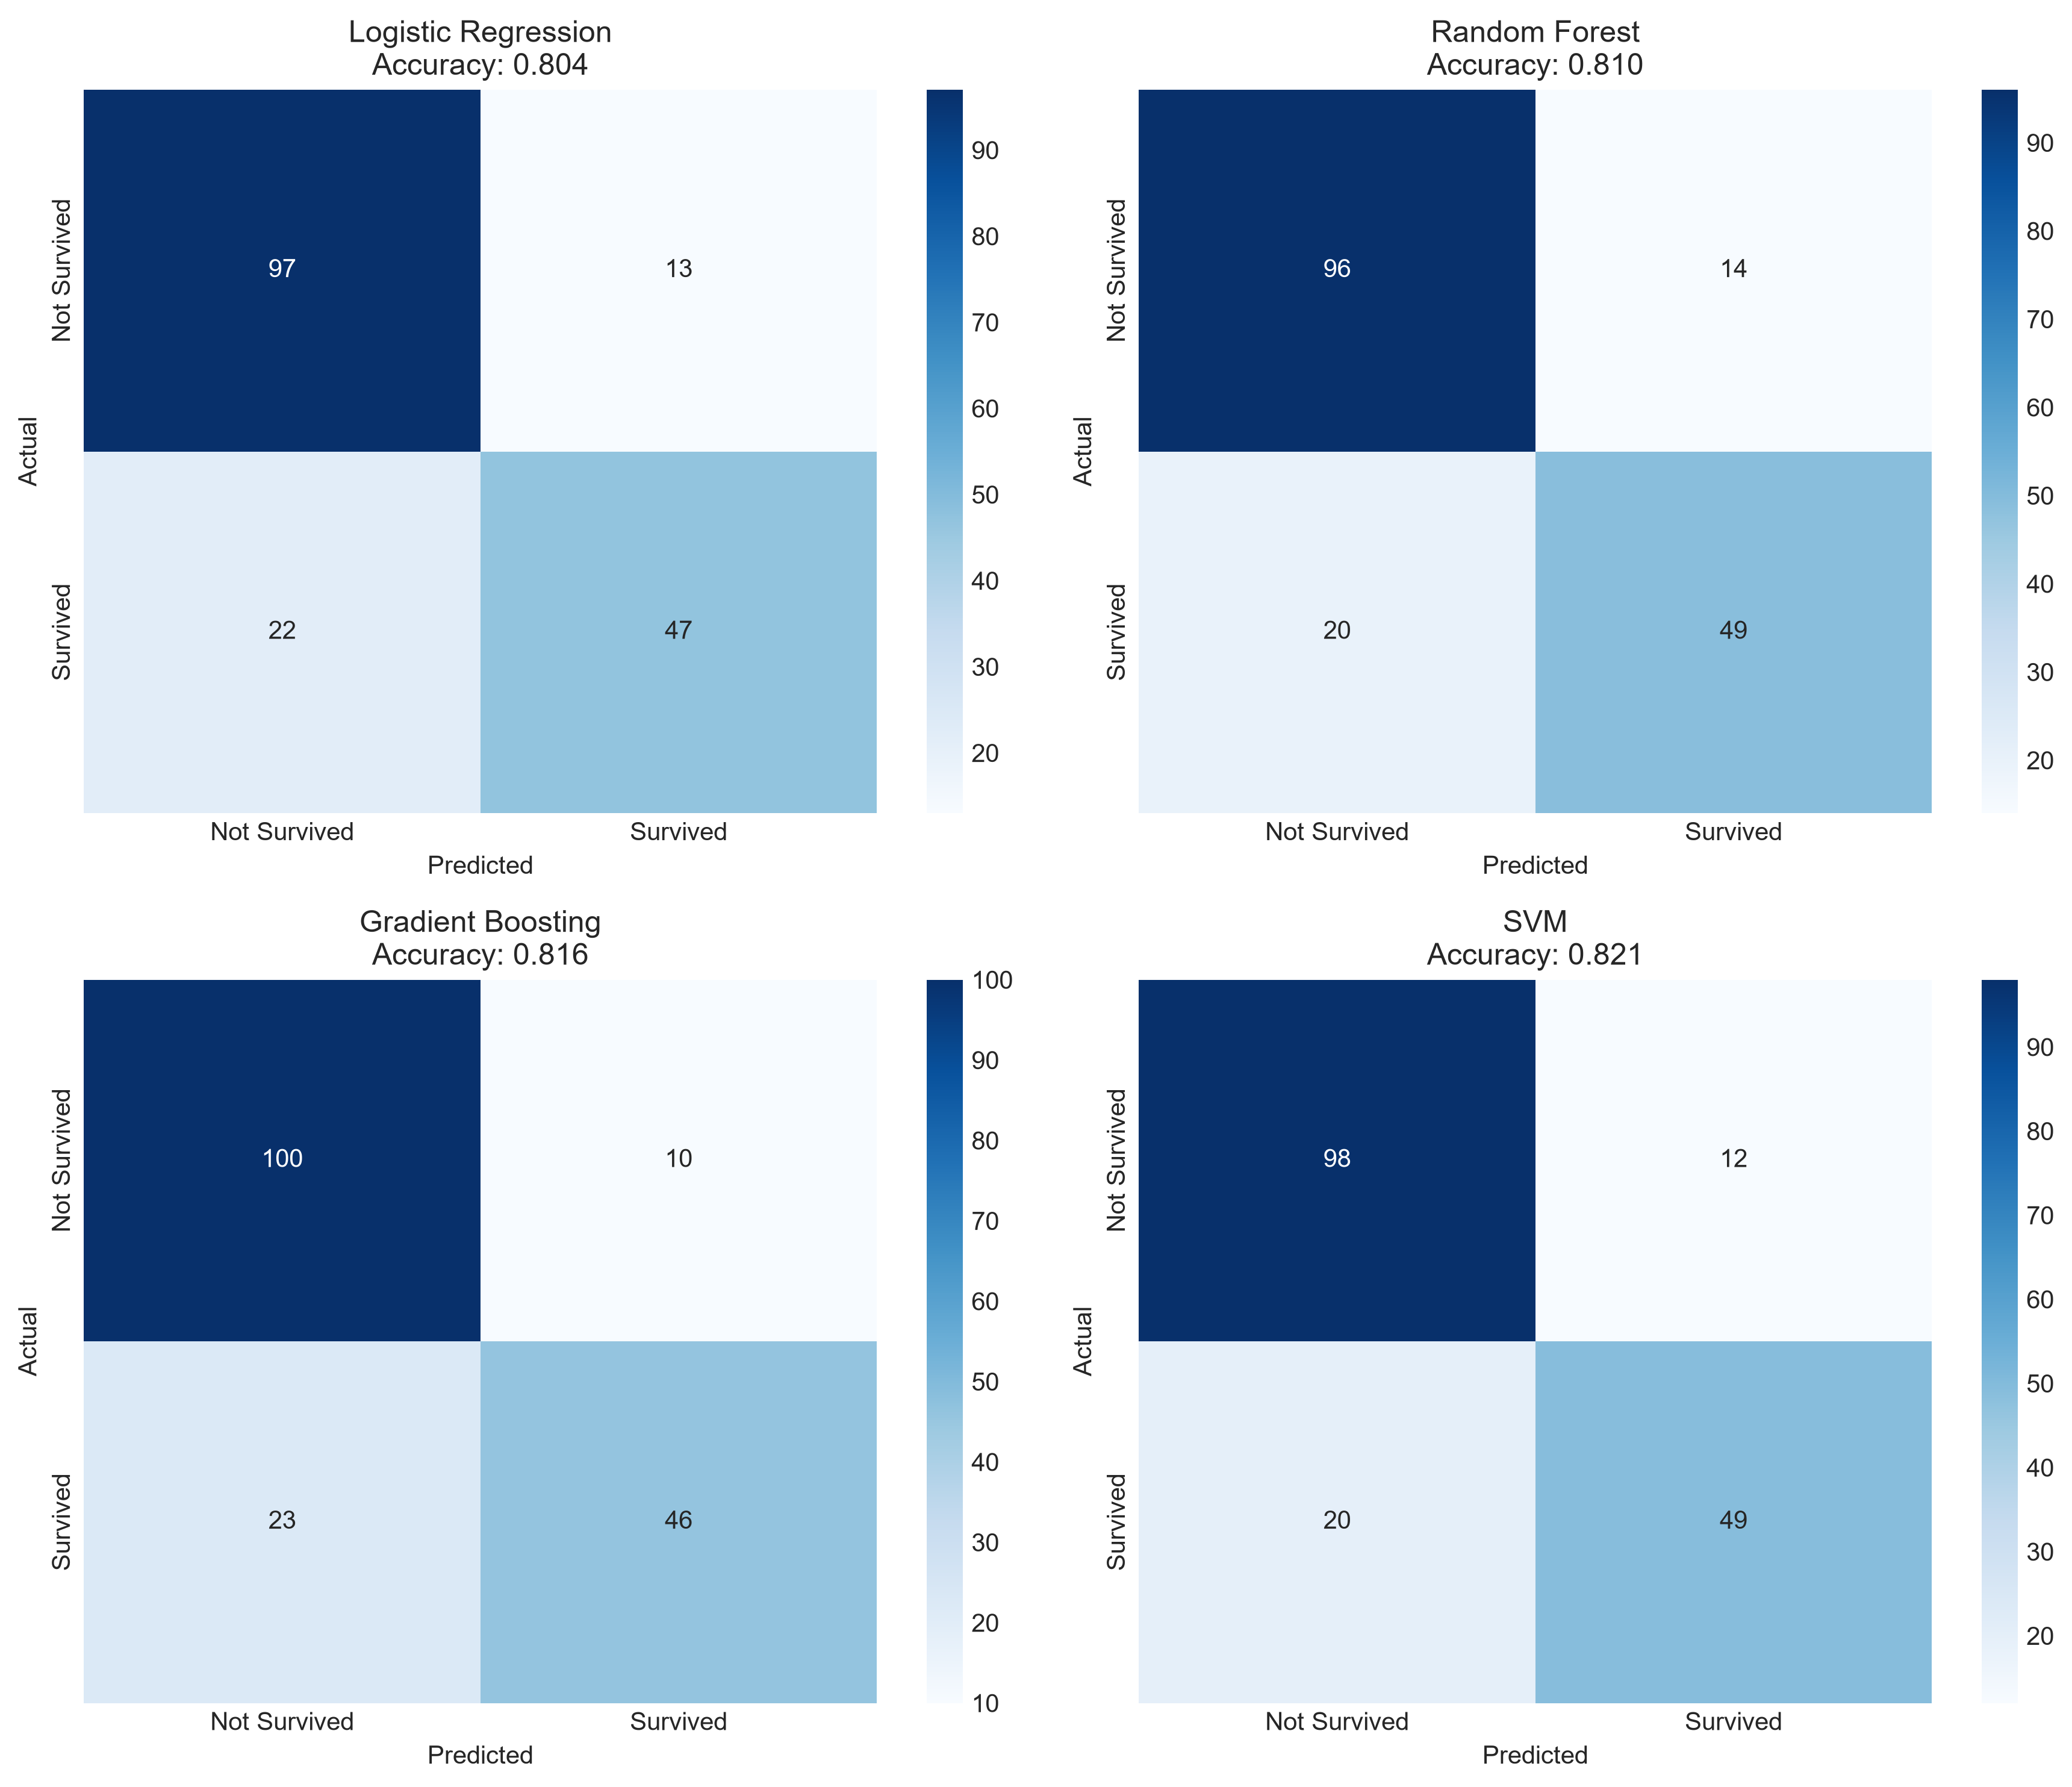

In [162]:
# ----- Fix: Convert Pclass to numeric if it's string -----
if df_processed['Pclass'].dtype == 'object':
    # Option A: map
    pclass_map = {'First': 1, 'Second': 2, 'Third': 3}
    df_processed['Pclass'] = df_processed['Pclass'].map(pclass_map).astype(int)
    # Option B: if mapping fails, use label encoder
    # from sklearn.preprocessing import LabelEncoder
    # le = LabelEncoder()
    # df_processed['Pclass'] = le.fit_transform(df_processed['Pclass']) + 1

# Also ensure no other columns are objects (except those you will encode later)
# For safety, convert all object columns to string then label encode (except those you intend to keep as categorical)
for col in df_processed.select_dtypes(include=['object']).columns:
    if col not in ['Sex', 'Embarked']:   # we'll encode these separately later
        df_processed[col] = df_processed[col].astype(str)
        # if it's a numeric-like string, convert it
        try:
            df_processed[col] = pd.to_numeric(df_processed[col])
        except:
            pass  # leave as object, will be encoded later if needed

Figure 13_roc_curves

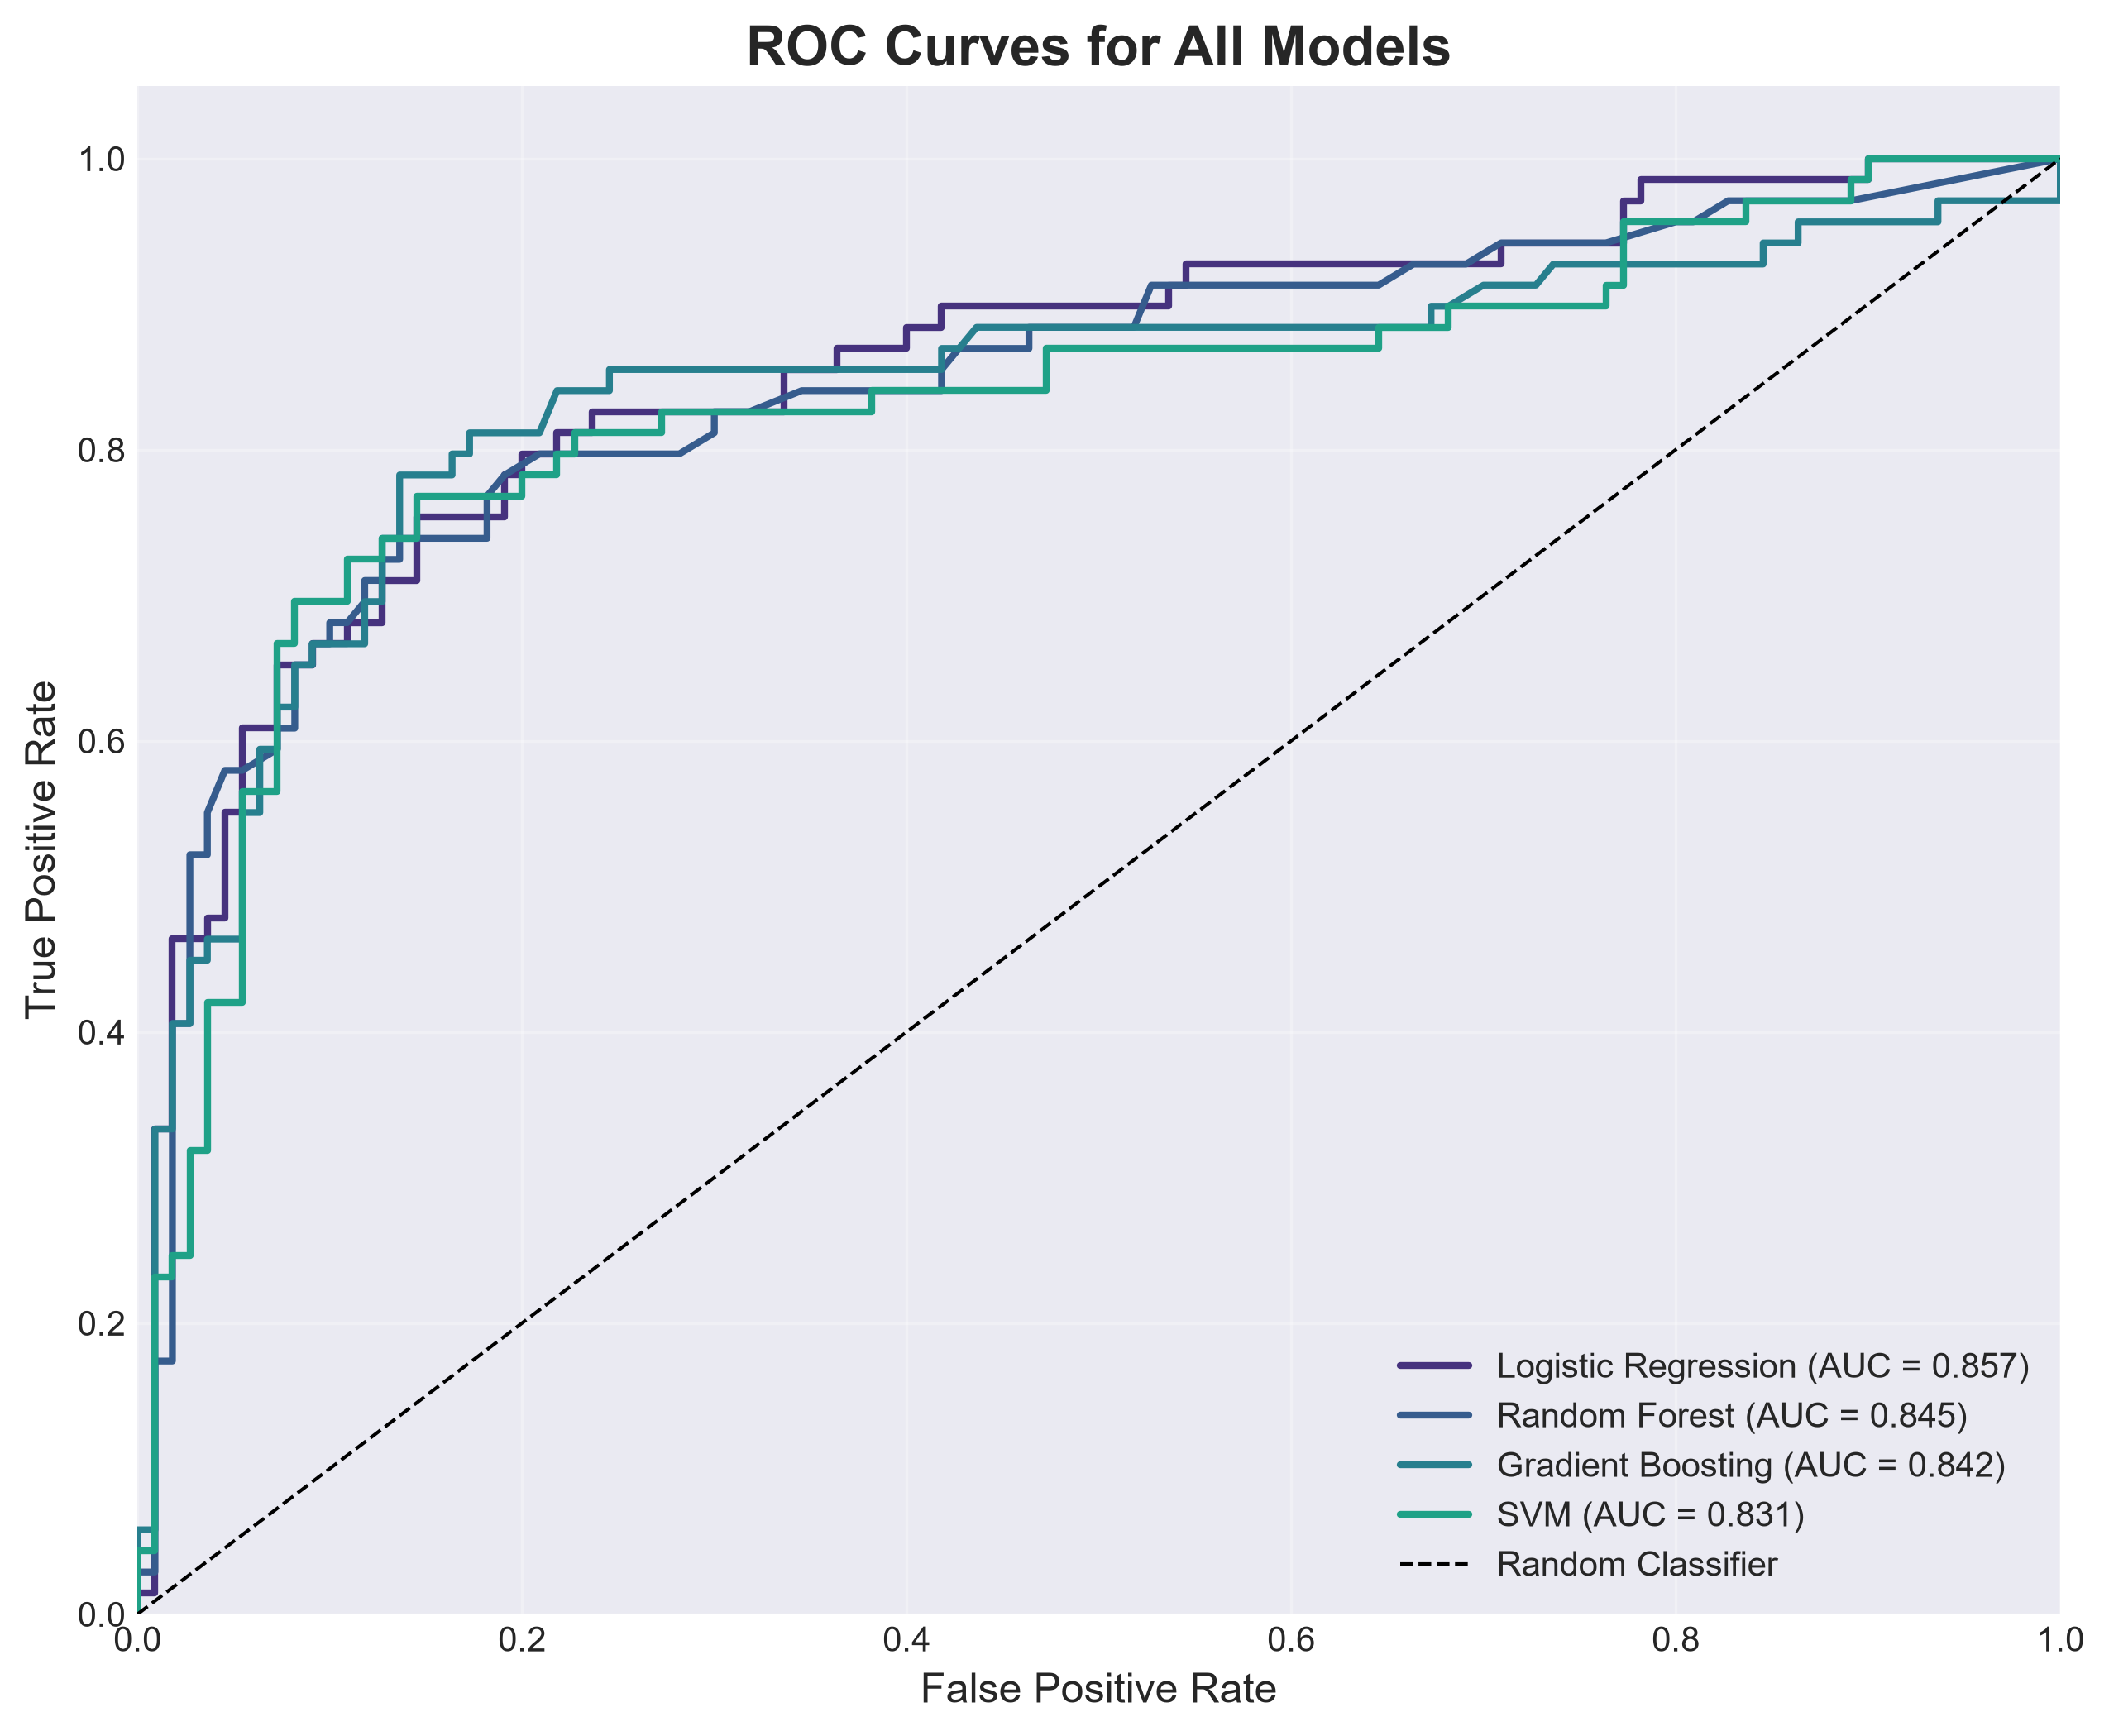

In [163]:
# ---- FIX: Convert Pclass strings to numbers ----
if df['Pclass'].dtype == 'object':
    pclass_map = {'First': 1, 'Second': 2, 'Third': 3}
    df['Pclass'] = df['Pclass'].map(pclass_map).astype(int)

In [164]:
# Check if Random Forest is fitted
from sklearn.utils.validation import check_is_fitted
try:
    check_is_fitted(models['Random Forest'])
    print("Random Forest is fitted.")
except:
    print("Random Forest is NOT fitted.")

Random Forest is NOT fitted.


Figure 14_feature_importance – Sex, Age, Fare are top features.

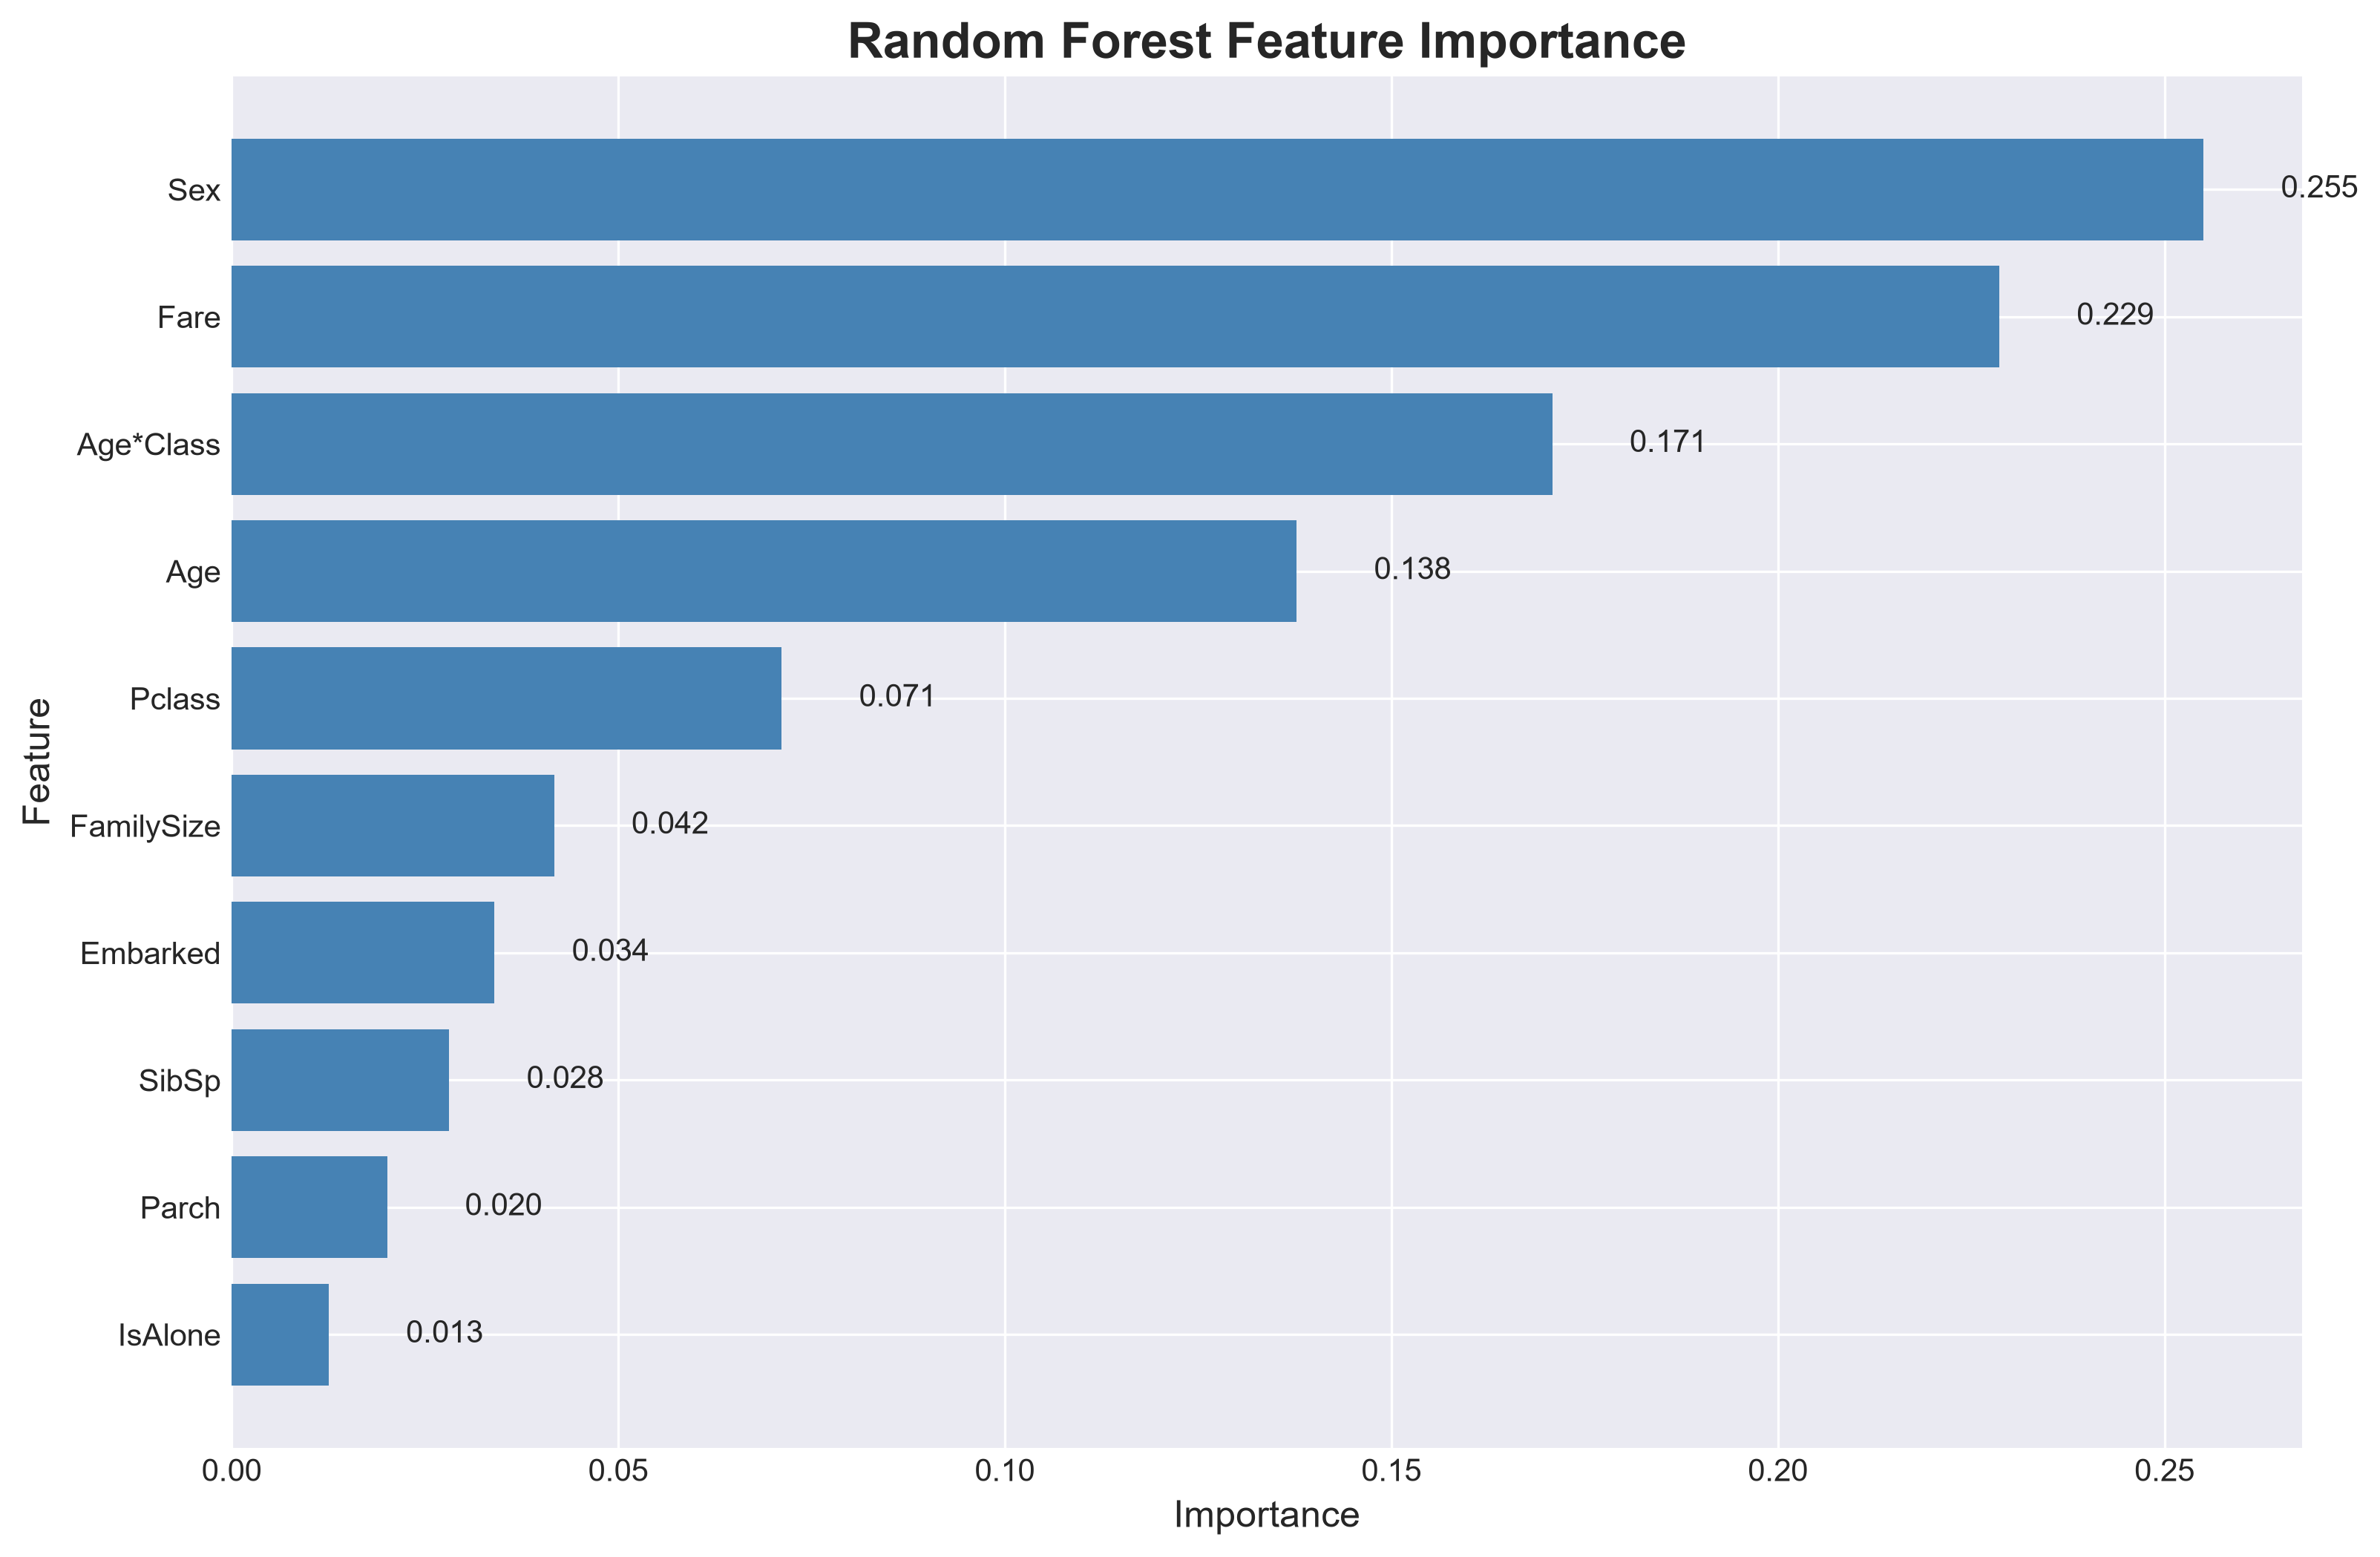

All comparison visualizations saved to output directory!

Step 7: Hyperparameter Tuning (Best Model)

In [165]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

Best performing model: Random Forest

Tuning Random Forest hyperparameters...
Best parameters: {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.8315
Tuned model test accuracy: 0.8324

Step 8: Save the Best Model

In [166]:
# 1. Force all columns in X_train_scaled and X_test_scaled to be numeric

print("\n Checking and converting data types in scaled features")
for col in X_train_scaled.columns:
    if X_train_scaled[col].dtype == 'object':
        print(f"   Column '{col}' is object. Converting to numeric...")
        X_train_scaled[col] = pd.to_numeric(X_train_scaled[col], errors='coerce')
        X_test_scaled[col] = pd.to_numeric(X_test_scaled[col], errors='coerce')
        # Fill any NaNs that appeared
        X_train_scaled[col] = X_train_scaled[col].fillna(0)
        X_test_scaled[col] = X_test_scaled[col].fillna(0)
    # Also handle if column is of type 'string' or 'category'
    elif pd.api.types.is_string_dtype(X_train_scaled[col]):
        print(f"   Column '{col}' is string dtype. Converting...")
        X_train_scaled[col] = pd.to_numeric(X_train_scaled[col], errors='coerce').fillna(0)
        X_test_scaled[col] = pd.to_numeric(X_test_scaled[col], errors='coerce').fillna(0)
    # If still not numeric, force conversion to float
    if not np.issubdtype(X_train_scaled[col].dtype, np.number):
        print(f"   Column '{col}' is not numeric (dtype={X_train_scaled[col].dtype}). Forcing to float...")
        X_train_scaled[col] = X_train_scaled[col].astype(float)
        X_test_scaled[col] = X_test_scaled[col].astype(float)

# Double‑check that all columns are now numeric
print("\nFinal data types in X_train_scaled:")
print(X_train_scaled.dtypes)
if any(X_train_scaled.dtypes == 'object'):
    print("WARNING: There are still object columns in X_train_scaled!")
    print("Columns with object dtype:", X_train_scaled.columns[X_train_scaled.dtypes == 'object'].tolist())
else:
    print("All columns are numeric. Good to go.")


# 2. If best_model is not defined, train models

try:
    best_model
except NameError:
    print("\nbest_model not defined. Running training now...")
    
    # Ensure models are defined
    try:
        models
    except NameError:
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
        from sklearn.svm import SVC
        models = {
            'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
            'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
            'SVM': SVC(probability=True, random_state=42)
        }
        print("Models defined.")

    # Run training
    results = {}
    predictions = {}
    print("Training models...")
    for name, model in models.items():
        print(f"\n--- {name} ---")
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        accuracy = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
        results[name] = {
            'Accuracy': accuracy,
            'ROC AUC': roc_auc,
            'CV Mean': cv_scores.mean(),
            'CV Std': cv_scores.std()
        }
        predictions[name] = y_pred
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  ROC AUC: {roc_auc:.4f}")
        print(f"  CV Mean: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

    # Pick best model
    best_model_name = max(results, key=lambda x: results[x]['Accuracy'])
    best_model = models[best_model_name]
    tuned_accuracy = results[best_model_name]['Accuracy']
    print(f"\n✅ Training complete. Best model: {best_model_name} (accuracy {tuned_accuracy:.4f})")


# 3. Save everything

print("\n Saving models and encoders")
model_path = os.path.join(MODEL_DIR, 'titanic_best_model.pkl')
joblib.dump(best_model, model_path)
print(f"Best model saved to: {model_path}")

scaler_path = os.path.join(MODEL_DIR, 'scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")

encoders_path = os.path.join(MODEL_DIR, 'encoders.pkl')
joblib.dump({'sex': le_sex, 'embarked': le_embarked}, encoders_path)
print(f"Encoders saved to: {encoders_path}")



 Checking and converting data types in scaled features

Final data types in X_train_scaled:
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked         int64
class          float64
who            float64
adult_male     float64
deck           float64
embark_town    float64
alive          float64
alone          float64
FamilySize     float64
IsAlone          int64
Age*Class      float64
dtype: object
All columns are numeric. Good to go.

 Saving models and encoders
Best model saved to: c:\Users\HP\Downloads\models\titanic_best_model.pkl
Scaler saved to: c:\Users\HP\Downloads\models\scaler.pkl
Encoders saved to: c:\Users\HP\Downloads\models\encoders.pkl


Step 9: Summary Report

In [167]:
print(f"""
PROJECT: Titanic Survival Prediction

DATASET INFORMATION:
- Total samples: {len(df)}
- Features: {df.shape[1]}
- Survival Rate: {df['Survived'].mean():.2%}

MISSING VALUES HANDLED:
- Age: {df['Age'].isnull().sum()} missing values (filled with median: {age_median:.2f})
- Embarked: {df['Embarked'].isnull().sum()} missing values (filled with mode: {df['Embarked'].mode()[0]})
- Fare: {df['Fare'].isnull().sum()} missing values (filled with median: {fare_median:.2f})
- Cabin: Dropped
- Ticket: Dropped
- Name: Dropped

FEATURES USED:
- Pclass, Sex (Encoded), Age (Scaled), SibSp, Parch, Fare (Scaled), Embarked (Encoded)
- FamilySize (Engineered), IsAlone (Engineered), Age*Class (Engineered)

MODEL PERFORMANCE:
""")
for name, scores in results.items():
    print(f"{name}:")
    print(f"  - Accuracy: {scores['Accuracy']:.4f}")
    print(f"  - ROC AUC: {scores['ROC AUC']:.4f}")
    print(f"  - CV Score: {scores['CV Mean']:.4f} (+/- {scores['CV Std']:.4f})")

print(f"\nBEST MODEL: {best_model_name}")
print(f"Best Model Accuracy: {results[best_model_name]['Accuracy']:.4f} (tuned: {tuned_accuracy:.4f})")

print(f"\nOUTPUT FILES GENERATED:")
print(f"  - Data directory: {DATA_DIR}")
print(f"  - Output directory: {OUTPUT_DIR} (14 visualizations)")
print(f"  - Model directory: {MODEL_DIR} (3 files)")


PROJECT: Titanic Survival Prediction

DATASET INFORMATION:
- Total samples: 891
- Features: 15
- Survival Rate: 38.38%

MISSING VALUES HANDLED:
- Age: 177 missing values (filled with median: 28.00)
- Embarked: 2 missing values (filled with mode: S)
- Fare: 0 missing values (filled with median: 14.45)
- Cabin: Dropped
- Ticket: Dropped
- Name: Dropped

FEATURES USED:
- Pclass, Sex (Encoded), Age (Scaled), SibSp, Parch, Fare (Scaled), Embarked (Encoded)
- FamilySize (Engineered), IsAlone (Engineered), Age*Class (Engineered)

MODEL PERFORMANCE:

Logistic Regression:
  - Accuracy: 0.8324
  - ROC AUC: 0.8735
  - CV Score: 0.8175 (+/- 0.0298)
Random Forest:
  - Accuracy: 0.8156
  - ROC AUC: 0.8578
  - CV Score: 0.7979 (+/- 0.0347)
Gradient Boosting:
  - Accuracy: 0.8101
  - ROC AUC: 0.8555
  - CV Score: 0.8190 (+/- 0.0382)
SVM:
  - Accuracy: 0.8212
  - ROC AUC: 0.8361
  - CV Score: 0.8259 (+/- 0.0130)

BEST MODEL: Logistic Regression
Best Model Accuracy: 0.8324 (tuned: 0.8324)

OUTPUT FILES